### 方正证券-方正证券多因子选股系列研究之四：个股动量效应的识别及“球队硬币”因子构建

#### 思路

一篇思路很优秀的研报，研报主要从马科维兹的论文出发，举了两个非常有代表的例子

1. 抛一枚硬币，当人们对其进行预测时，如果上一次是正面，那么更多的人们会倾向于预测下一次是反面。这就是潜在的“反转策略”。

2. 足球比赛的赛季初时，让人们预测这个赛季的冠军是哪知队伍，更多的人会倾向于预测赛季夺冠的队伍是上一次夺冠的队伍。这就是潜在的“动量策略”

为什么会这样呢？马科维兹将其总结为 “可知” 与 “不可知”。 当人们抛一枚硬币时，如果上次抛出了正面， 人们倾向于猜测下次是反面，这是因为人们对抛硬币这件活动本
身比较了解，对于其发生的概率比较确定， 即“抛硬币”这件事的“可知性”较高 ，因此人们会以 反转 的眼光来看待 抛硬币 ””。

而当一个新赛季开始时，如果让人们猜测哪只球队会夺冠，由于人们对新赛季的球队、球队的成员和团队磨合等不是很了解， 即“冠军是谁”这件事的“可知性”较低 ，因此只能以这些球队的历史成绩来考察它们，此时人们更倾向于猜测上赛季的冠军，依旧会在本赛季夺冠，总结来说，人们会以 动量 的眼光来看待 球队夺冠 。

但是上述逻辑在股票上往往又是相反的应用。

假设，我们可以将所有股票分为两组，可知组与不可知组。

可知组成为了硬币，人们观察其时，会做出反转的决策。例如，如果过去是上涨的，投资者认为后续应该反转，从而导致了超卖，股票又会补涨。成为了潜在的 “动量因子”

不可知组成为了球队，人们观察其时，会做出动量的决策，例如，如果过去式上涨的，投资者认为后续会继续上涨，从而导致了超买，股价又会补跌，成为了潜在的 “反转因子”


研报认为，波动率和换手率可以代表一只股票的可知性，股价走势稳定，投资者做出决策往往也就更加容易，变得“可知”，而如果波动率加剧，投资者很难做出决策，变得“不可知”

同理，如果换手率显著上升，投资者分歧加剧，也就意味着“不可知”，而换手率显著下降，则意味着投资者有相对一致的决策，“可知性”提高了

基于此，我们可以设计球队硬币因子

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from jqdatasdk import *
import plotly as py
import plotly.graph_objs as go
from plotly.offline import iplot, init_notebook_mode
import cufflinks
from plotly.subplots import make_subplots
from concurrent.futures import ProcessPoolExecutor
from backtrade import back_trade
cufflinks.go_offline(connected=True)
init_notebook_mode(connected=True)
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from  matplotlib.figure import Figure

d:\anaconda\envs\Yassin\lib\site-packages\requests\__init__.py:109: RequestsDependencyWarning: urllib3 (2.0.2) or chardet (5.0.0)/charset_normalizer (2.1.1) doesn't match a supported version!
  warnings.warn(


window.PlotlyConfig = {MathJaxConfig: 'local'};
 if (window.MathJax && window.MathJax.Hub && window.MathJax.Hub.Config) {window.MathJax.Hub.Config({SVG: {font: "STIX-Web"}});}
 if (typeof require !== 'undefined') {
 require.undef("plotly");
 requirejs.config({
 paths: {
 'plotly': ['https://cdn.plot.ly/plotly-2.12.1.min']
 }
 });
 require(['plotly'], function(Plotly) {
 window._Plotly = Plotly;
 });
 }

window.PlotlyConfig = {MathJaxConfig: 'local'};
 if (window.MathJax && window.MathJax.Hub && window.MathJax.Hub.Config) {window.MathJax.Hub.Config({SVG: {font: "STIX-Web"}});}
 if (typeof require !== 'undefined') {
 require.undef("plotly");
 requirejs.config({
 paths: {
 'plotly': ['https://cdn.plot.ly/plotly-2.12.1.min']
 }
 });
 require(['plotly'], function(Plotly) {
 window._Plotly = Plotly;
 });
 }

In [2]:
df = pd.read_hdf("price_not_fq.hdf", key = 'data')
df.sort_values(['code', 'time'], ascending=True, inplace = True)
df = df.reset_index(drop = True)
df

,code,time,open,high,low,close,pre_close,volume,money
0,000001.XSHE,2012-01-04,15.59,15.59,15.15,15.16,15.59,147910.98,2.275637e+05
1,000001.XSHE,2012-01-05,15.16,15.55,15.13,15.39,15.16,244080.05,3.758806e+05
2,000001.XSHE,2012-01-06,15.35,15.51,15.15,15.35,15.39,133151.15,2.041437e+05
3,000001.XSHE,2012-01-09,15.36,15.81,15.25,15.78,15.35,221138.66,3.459387e+05
4,000001.XSHE,2012-01-20,16.73,16.94,16.32,16.78,15.78,586675.66,9.728268e+05
...,...,...,...,...,...,...,...,...,...
9070788,689009.XSHG,2023-06-15,35.70,37.39,35.37,36.62,35.96,11812696.00,4.304630e+08
9070789,689009.XSHG,2023-06-16,36.45,36.70,35.67,36.01,36.62,9177317.00,3.303961e+08
9070790,689009.XSHG,2023-06-19,35.77,35.95,34.17,34.61,36.01,13285598.00,4.636696e+08
9070791,689009.XSHG,2023-06-20,34.51,37.34,34.32,36.09,34.61,17367938.00,6.230034e+08


In [3]:
def show_mom_back(my_df, fac_col:str, ret_col:str) -> pd.DataFrame:
    df = my_df.dropna(how = 'any')
    df.dropna(how = 'any', inplace = True)
    def judge(a, b):
        if a > 0 and b > 0 or a < 0 and  b < 0:
            return 1
        else:
            return 0
    def calc_net_mom_ratio(df):
        S = df["cond"].sum()
        M = df.shape[0]
        return (2 * S - M) / M

    # extra_1 超额因子值  extra_2 超额收益率
    df["extra_1"] = df.groupby("time")[fac_col].apply(lambda x: x - x.mean())
    df["extra_2"] = df.groupby("time")[ret_col].apply(lambda x: x - x.mean())
    # cond 如果为 1 表示发生了动量效应，否则发生了反转效应
    df["cond"] = df.apply(lambda x: judge(x["extra_1"], x["extra_2"]), axis = 1)
    # 净动量比例 = (动量效应数量 - 反转效应数量) / 总天数
    g = df.groupby("time").apply(calc_net_mom_ratio).reset_index(drop = True)
    show_df = pd.DataFrame()
    show_df["time"] = sorted(list(set(df["time"].tolist())))
    show_df["net_mom_ratio"] = g
    # print(show_df)
    
    # 均动量比例为过去的净动量比例的均值
    Mean1 = show_df["net_mom_ratio"].mean()

    #用 均动量比例 除以 净动量比例的标准差， 得到了稳净动量比例
    Std1 = show_df["net_mom_ratio"].std()
    Stable_net_mom_ratio = Mean1 / Std1

    # 最后输出多少比例净动量比例大于 0
    print("net_mom_ratio > 0 的比例为：", show_df[show_df["net_mom_ratio"] > 0].shape[0] / show_df.shape[0])
    # 输出稳净动量比例和均动量比例
    print("Avg_net_mom_ratio: ", Mean1)
    print("Stable_net_mom_ratio: ", Stable_net_mom_ratio)

    draw_df = show_df[["time", "net_mom_ratio"]]
    return draw_df


In [4]:
def show_tactic(df):
    # fig = Figure(figsize=(20, 10))
    df["time"] = pd.to_datetime(df["time"])
    Fig, axes  = plt.subplots(1, 2, figsize = (20, 10))
    # 首先展示净动量比例随时间的变化图，画散点图
    axes[0].scatter(df["time"], df["net_mom_ratio"])
    axes[0].set_title("net_mom_ratio")
    # 随后展示净动量比例的分布情况，hist 展示
    axes[1].hist(df["net_mom_ratio"], bins = 10)
    axes[1].set_title("net_mom_ratio distribution")
    plt.show()

In [5]:
def show(df, Name, Type = 0):
    '''
        Type = 0 时 用 plotly 绘图
        Type = 1 时 用 matplotlib 绘图
    '''
    if Type == 0:
        df["date"] = pd.to_datetime(df["date"])
        trace0 = go.Scatter(x = df["date"], y = df["ret_0"], name = "group_0")
        trace1 = go.Scatter(x = df["date"], y = df["ret_1"], name = "group_1")
        trace2 = go.Scatter(x = df["date"], y = df["ret_2"], name = "group_2")
        trace3 = go.Scatter(x = df["date"], y = df["ret_3"], name = "group_3")
        trace4 = go.Scatter(x = df["date"], y = df["ret_4"], name = "group_4")
        trace5 = go.Scatter(x = df["date"], y = df["ret_5"], name = "group_5")
        trace6 = go.Scatter(x = df["date"], y = df["ret_6"], name = "group_6")
        trace7 = go.Scatter(x = df["date"], y = df["ret_7"], name = "group_7")
        trace8 = go.Scatter(x = df["date"], y = df["ret_8"], name = "group_8")
        trace9 = go.Scatter(x = df["date"], y = df["ret_9"], name = "group_9")

        fig = make_subplots(specs=[[{'secondary_y': True}]])
        
        data = [trace0, trace1, trace2, trace3, trace4, trace5, trace6, trace7, trace8, trace9]
        fig.add_traces(data)

        fig.add_trace(
            go.Scatter(x=df["date"], y=df["ret_0"] / df["ret_9"], name="多空差异"),
            secondary_y=True,
        )
        
        fig.update_layout(
            title = Name, 
            xaxis_title = "Date",
            yaxis_title = "Return",
        )

        fig.show()
    else:

        Fig, axes  = plt.subplots(2, 1, figsize = (20, 10))
        for i in range(0, 10):
            axes[0].plot(df["date"], df["ret_{}".format(i)], label = "group_{}".format(i))
        axes[0].legend()
        axes[0].set_title(Name)
        
        axes[1].plot(df["date"], df["ret_0"] / df["ret_9"], label = "call_put_diff")
        axes[1].legend()
        
        plt.show()

首先，我们来看看过去一段时间动量策略和反转策略的表现

用传统的过去一段时间的收益率作为因子。

In [6]:
def calc_ret(df):
    g = df.rolling(20)["ret"].apply(np.prod)
    df["ret_20"] = g
    return df


df["ret"] = df["close"] / df["pre_close"]
df = df.groupby("code").apply(calc_ret)
df["ret_20"] -= 1
df["ret_20_after"] = df.groupby("code")["ret_20"].shift(-20)
df = df.reset_index(drop = True)
df

,code,time,open,high,low,close,pre_close,volume,money,ret,ret_20,ret_20_after
0,000001.XSHE,2012-01-04,15.59,15.59,15.15,15.16,15.59,147910.98,2.275637e+05,0.972418,NaN,0.087731
1,000001.XSHE,2012-01-05,15.16,15.55,15.13,15.39,15.16,244080.05,3.758806e+05,1.015172,NaN,0.079922
2,000001.XSHE,2012-01-06,15.35,15.51,15.15,15.35,15.39,133151.15,2.041437e+05,0.997401,NaN,0.083388
3,000001.XSHE,2012-01-09,15.36,15.81,15.25,15.78,15.35,221138.66,3.459387e+05,1.028013,NaN,0.069075
4,000001.XSHE,2012-01-20,16.73,16.94,16.32,16.78,15.78,586675.66,9.728268e+05,1.063371,NaN,0.008343
...,...,...,...,...,...,...,...,...,...,...,...,...
9070788,689009.XSHG,2023-06-15,35.70,37.39,35.37,36.62,35.96,11812696.00,4.304630e+08,1.018354,0.055027,NaN
9070789,689009.XSHG,2023-06-16,36.45,36.70,35.67,36.01,36.62,9177317.00,3.303961e+08,0.983342,0.032397,NaN
9070790,689009.XSHG,2023-06-19,35.77,35.95,34.17,34.61,36.01,13285598.00,4.636696e+08,0.961122,-0.017599,NaN
9070791,689009.XSHG,2023-06-20,34.51,37.34,34.32,36.09,34.61,17367938.00,6.230034e+08,1.042762,0.032027,NaN


net_mom_ratio > 0 的比例为： 0.5307608299963597
Avg_net_mom_ratio:  -0.0007033307915579647
Stable_net_mom_ratio:  -0.006188009816833513


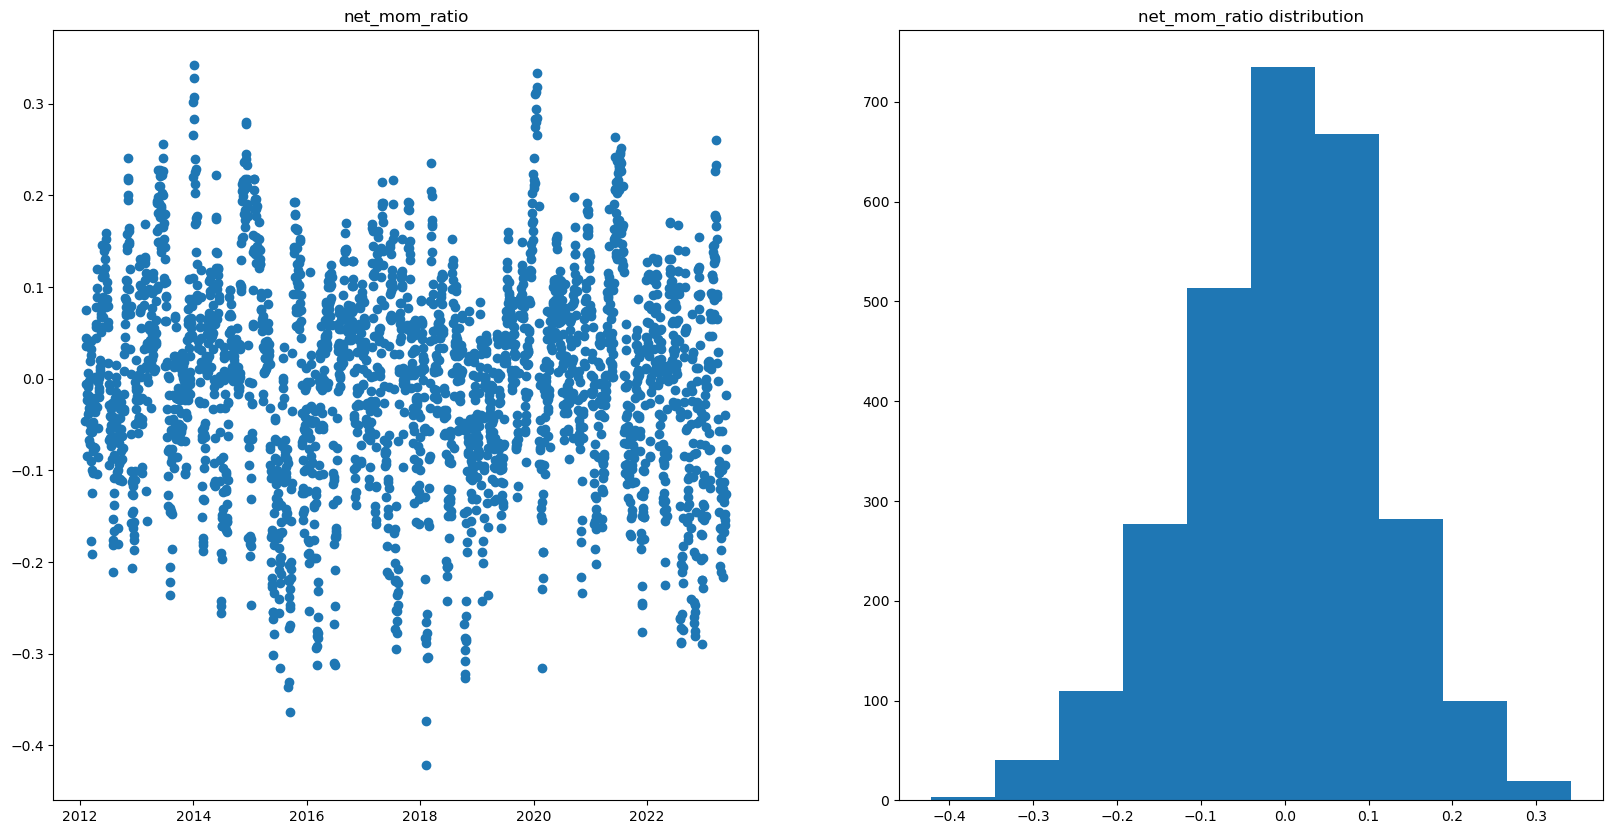

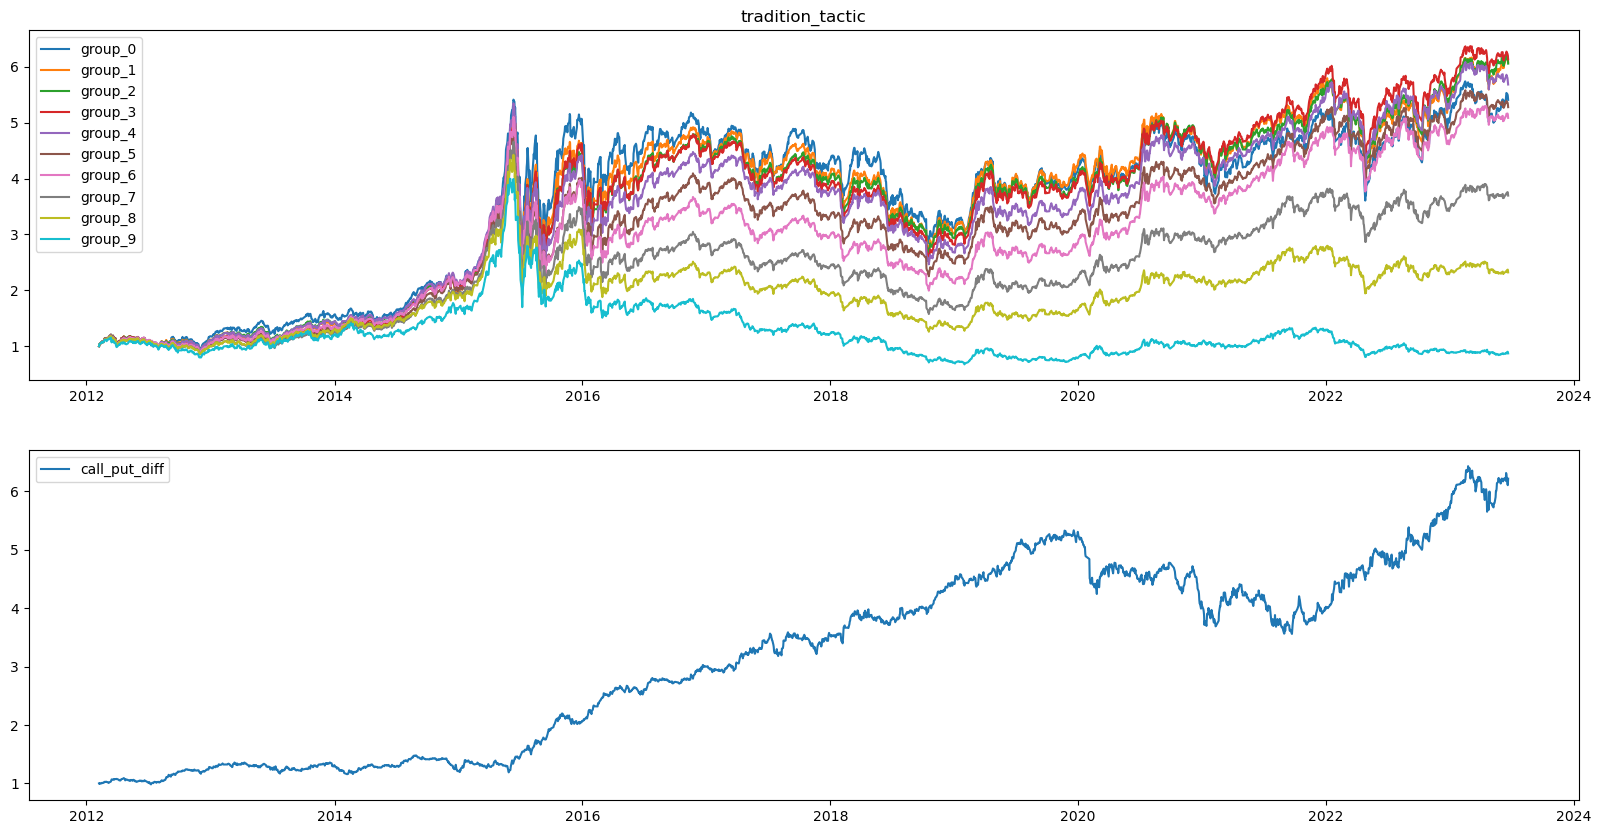

In [7]:

tradtion_tactic = show_mom_back(df, fac_col = "ret_20", ret_col = "ret_20_after")
show_tactic(tradtion_tactic)
tradtion_tactic_df = back_trade(df[["time", "code", "ret_20"]], tar_col = "ret_20")
show(tradtion_tactic_df, "tradition_tactic", Type = 1)

可以看到，动量效应发生的次数更多，大概有 53% 的时间内发生的是动量效应，但是超额收益为负， 这其实说明，我们在一定程度上把一些发生“动量效应”的股票也识别为“反转效应”，拖累了整体的表现

#### 日间波动率的可知性

我们认为波动率和换手率的变化量可以代表一支股票表现的“可知性”，即更像硬币还是更像球队。波动率低，表明股价走势相对稳定，投资者对其未来趋势做出判断也更加容易，而换手率降低，则表示投资者对股票的意见分歧逐渐减少，也是“可知性”提高的表现。

用过去20天的收益率的均值和标准差分别当作日间的波动率和收益率

将波动率小于市场均值的股票，视为“硬币”， 波动率大于市场均值的股票，视为 “球队”

对于硬币型股票，我们认为后续更可能发生动量效应，我们令其因子值乘以 -1，对于球队型股票，我们认为后续更可能发生反转，因子值不变

In [8]:
# 首先我们来计算过去 20 天的日收益率的 std
def calc_vol(df):
    g = df.rolling(20)["ret"].apply(np.std)
    df["Vol_between_day"] = g
    return df
df = df.groupby("code").apply(calc_vol)

net_mom_ratio > 0 的比例为： 0.3902439024390244
Avg_net_mom_ratio:  -0.01897254945661426
Stable_net_mom_ratio:  -0.2295938528040909


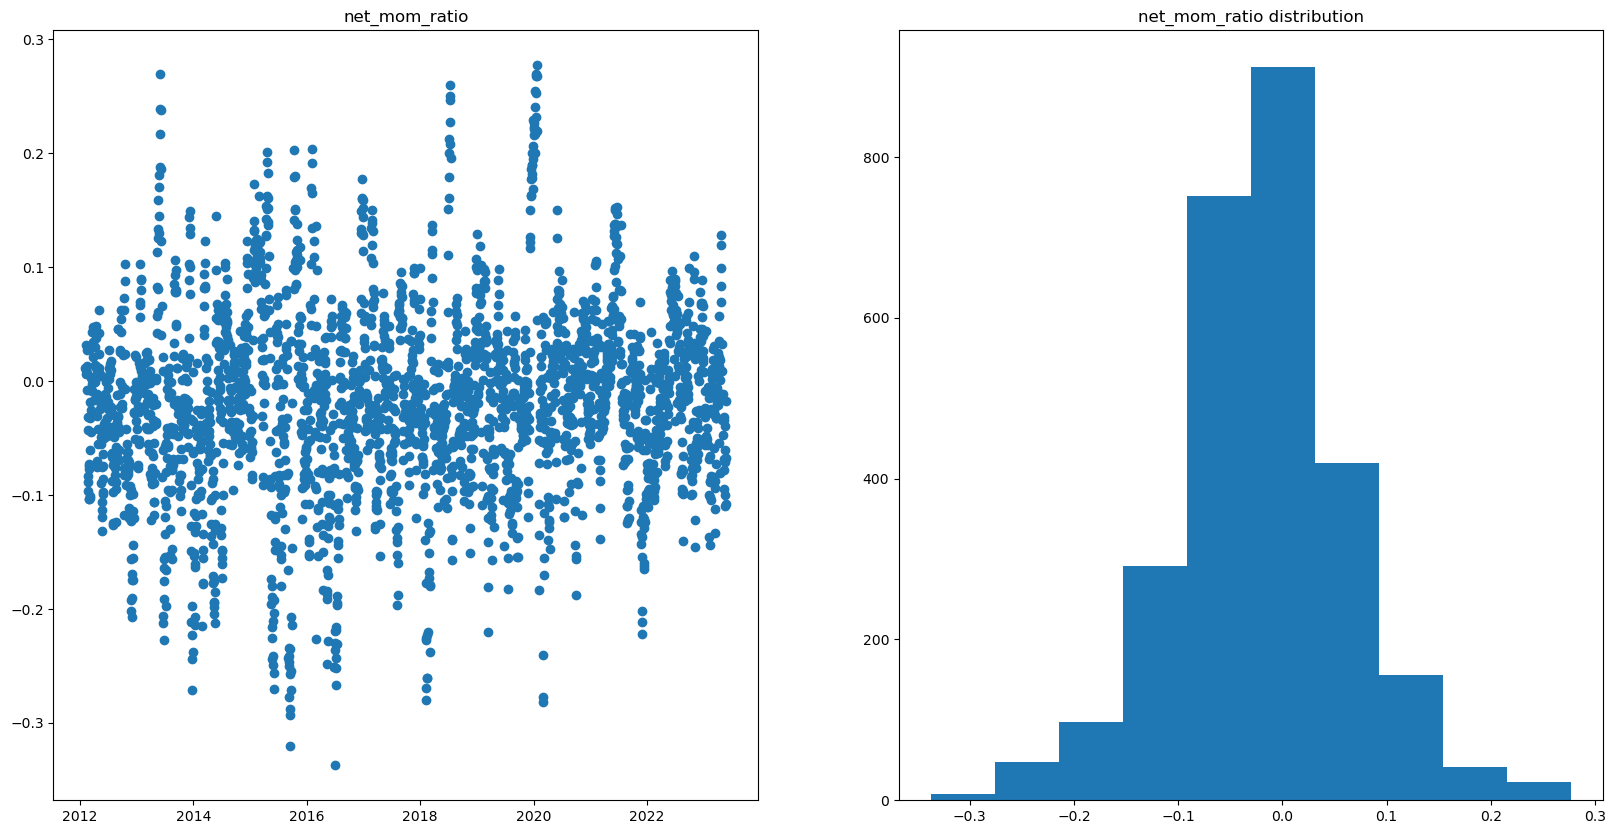

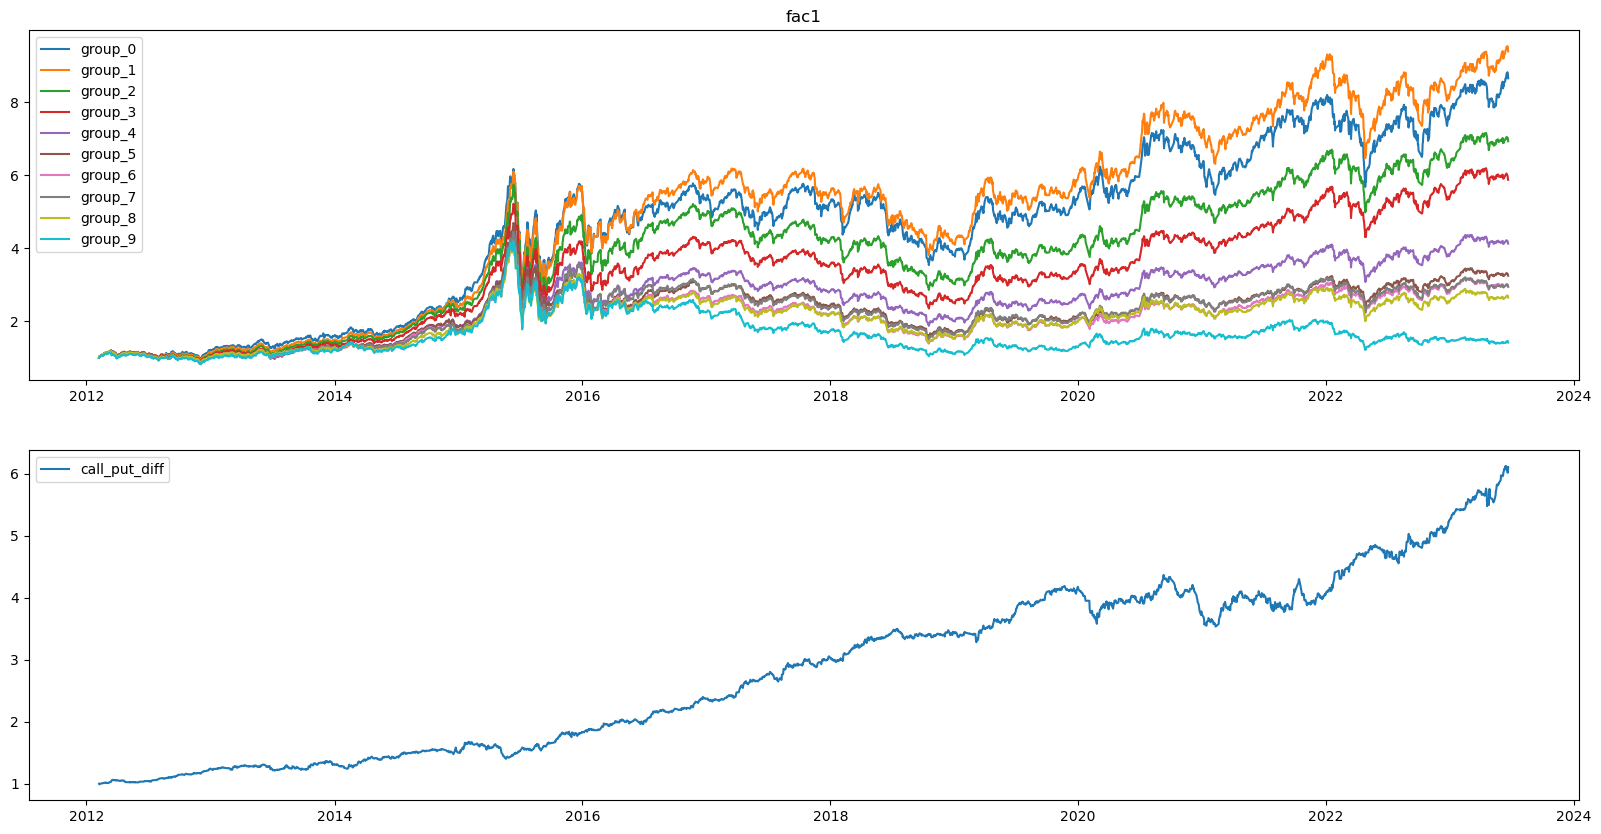

In [9]:
# 因为有很多小市值的股票，所以直接用 指数的 波动率是不太合适的，这里直接使用全市场的截面数据

g = df.groupby("time", as_index = False)["Vol_between_day"].mean()
g.columns = ["time", "market_avg_vol"]
df = pd.merge(df, g, on = 'time', how = 'left')
df["flag"] = df.apply(lambda x: 1 if x["Vol_between_day"] > x["market_avg_vol"] else -1, axis = 1)
df["fac1"] = df["ret_20"] * df["flag"]

tactic_1 = show_mom_back(df, fac_col = "fac1", ret_col = "ret_20_after")
show_tactic(tactic_1)
tactic_1_df = back_trade(df[["time", "code", "fac1"]], tar_col = "fac1")
show(tactic_1_df, "fac1", Type = 1)

此时我们可以看到，发生动量效应的比例为 0.39 比之前的 0.53 要小，即我们成功地识别出一些发生动量效应的个股。

多空收益拉成一条直线 因子整体表现非常良好

#### 日间换手率的可知性

“日间反转 换手翻转 ” 因子

将每只股票的换手率变化量与当日全市场的换手率变化量的均值做比较，我们认为换手率变化量高于市场均值的 股票为 球队型股票， 其未来将大概率发生 反转 效应 ；换手率变化量低于市场均值的为 硬币 股票，未来将大概率 发生动量 效应 。

In [10]:
# 先把流通股和行情数据 merge 一下
# 我这里的 float_share 是流通股本，单位是 万股， 所以看到的数据其实是 万分之多少
cap_df = pd.read_hdf("fin_df.hdf", key = 'data')
cap_df.columns = ["code", "time", "float_share"]
cap_df["time"] = pd.to_datetime(cap_df["time"])
df["time"] = pd.to_datetime(df["time"])
df = pd.merge(df, cap_df, on = ["code", "time"], how = 'left')
df["turnover_rate"] = df["volume"] / df["float_share"] 
df.drop("float_share", axis = 1, inplace = True)

net_mom_ratio > 0 的比例为： 0.3563887877684747
Avg_net_mom_ratio:  -0.02750365732301469
Stable_net_mom_ratio:  -0.3178375847422257


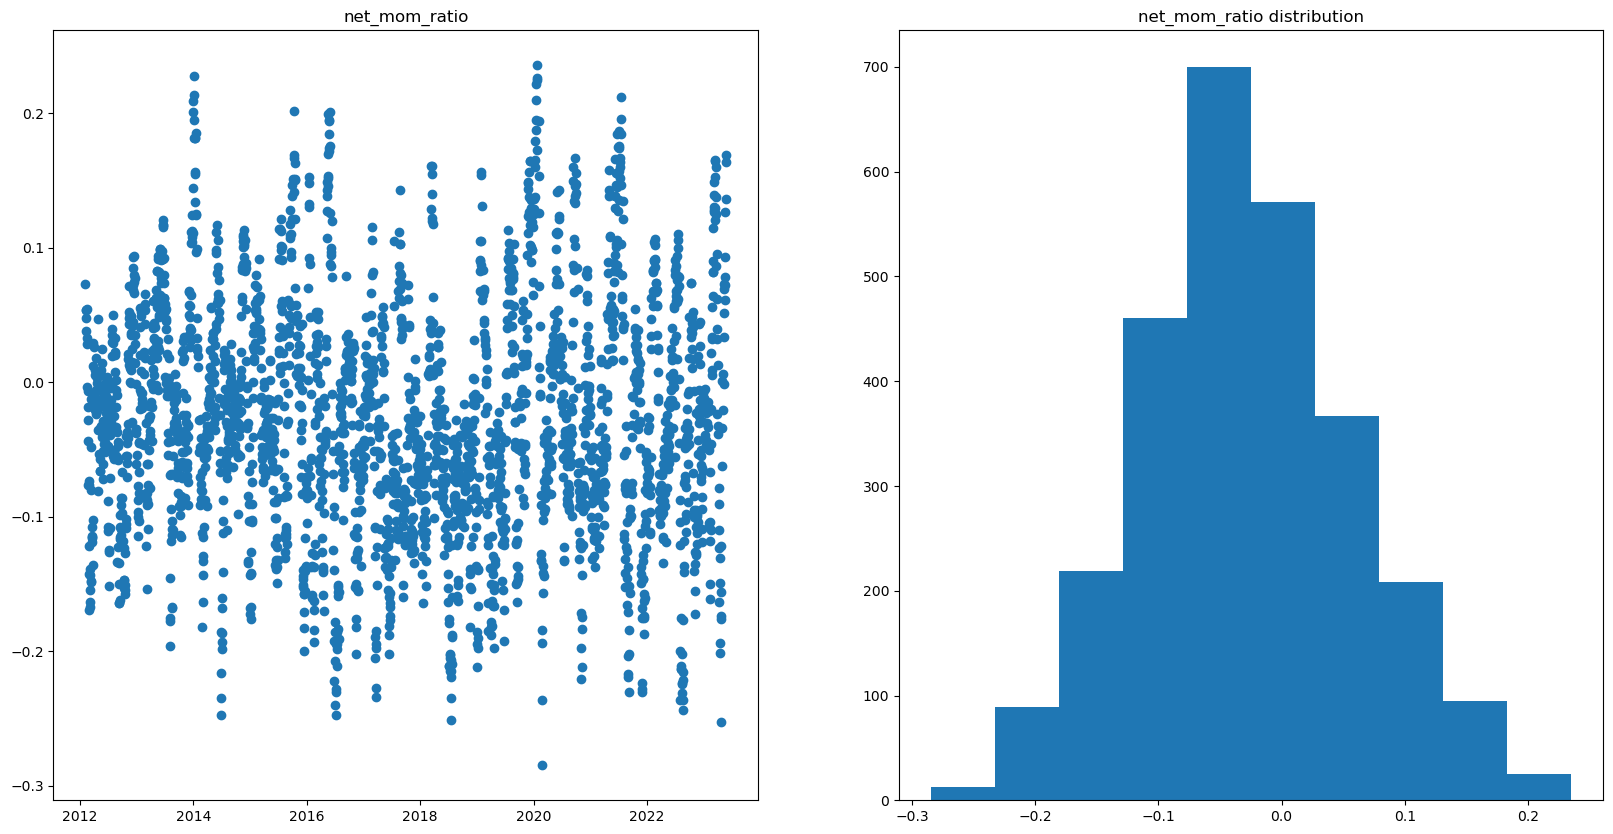

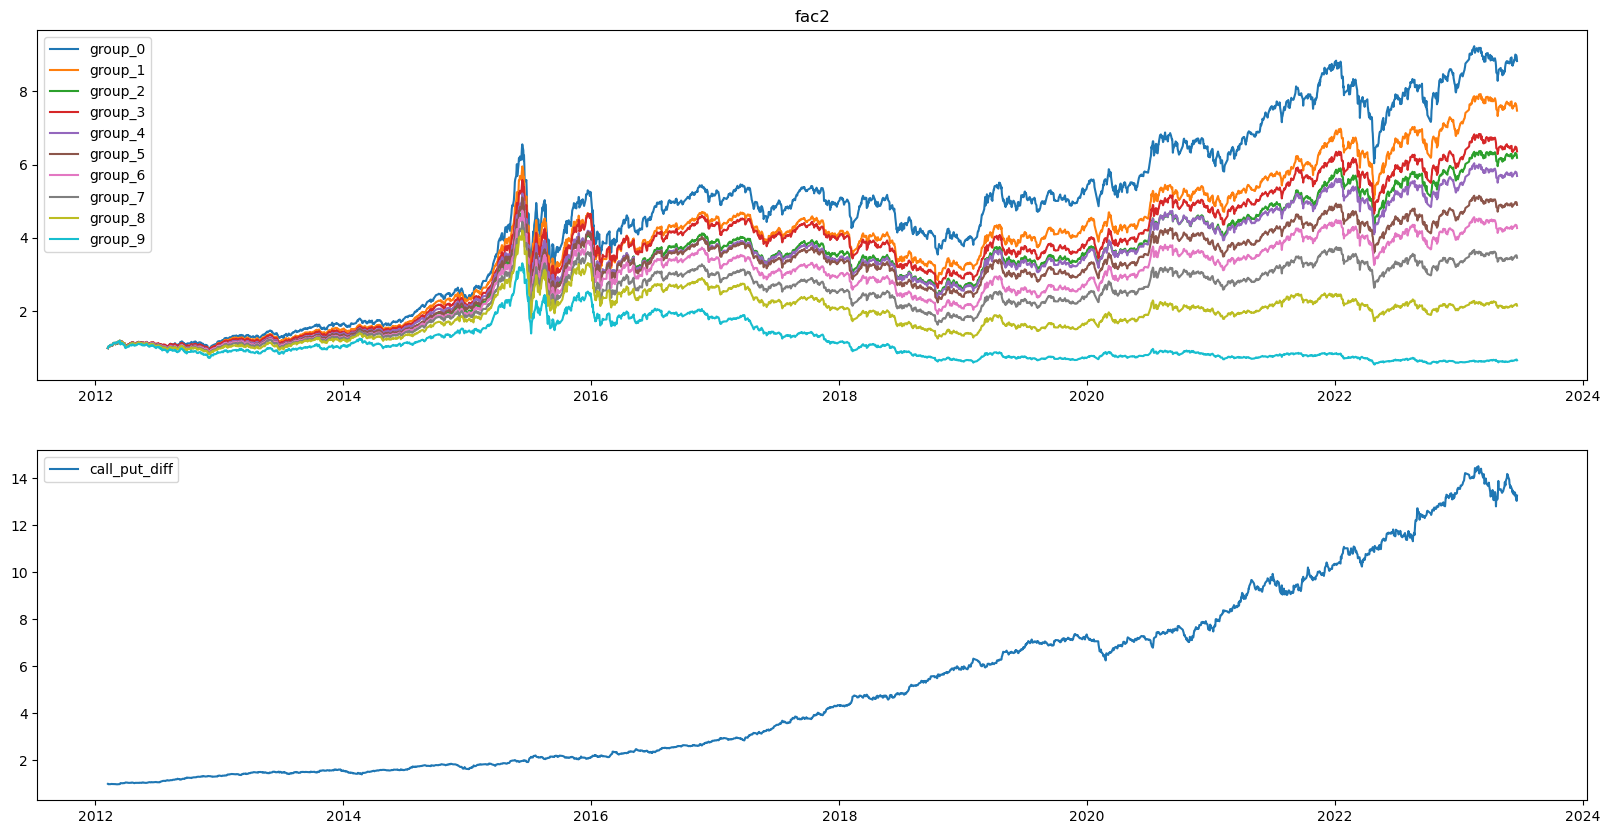

In [13]:
df["turnover_rate_change"] = df.groupby("code")["turnover_rate"].apply(lambda x: x - x.shift(1)) 
g = df.groupby("time", as_index = False)["turnover_rate_change"].mean()
g.columns = ["time", "turnover_rate_change_mean"]

df = pd.merge(df, g, on = 'time', how = 'left')

df["flag"] = df.apply(lambda x: 1 if x["turnover_rate_change"] > x["turnover_rate_change_mean"] else -1, axis = 1)
df["my_ret"] = df.apply(lambda x: (x["ret"] - 1) * x["flag"], axis = 1)


def calc_fac2(df):
    g = df.rolling(20)["my_ret"].apply(np.mean)
    df["fac2"] = g
    return df

df = df.groupby("code").apply(calc_fac2)

tactic_2 = show_mom_back(df, fac_col = "fac2", ret_col = "ret_20_after")
show_tactic(tactic_2)
tactic_2_df = back_trade(df[["time", "code", "fac2"]], tar_col = "fac2")
show(tactic_2_df, "fac2", Type = 1)

也是相当不错的因子，成功识别了更多属于动量效应的标的

#### 修正 - 日间收益率因子

接下来将两个因子等权合成，合成为 修正 - 日间收益率因子

net_mom_ratio > 0 的比例为： 0.3778667637422643
Avg_net_mom_ratio:  -0.02033620223819105
Stable_net_mom_ratio:  -0.23207589381170082


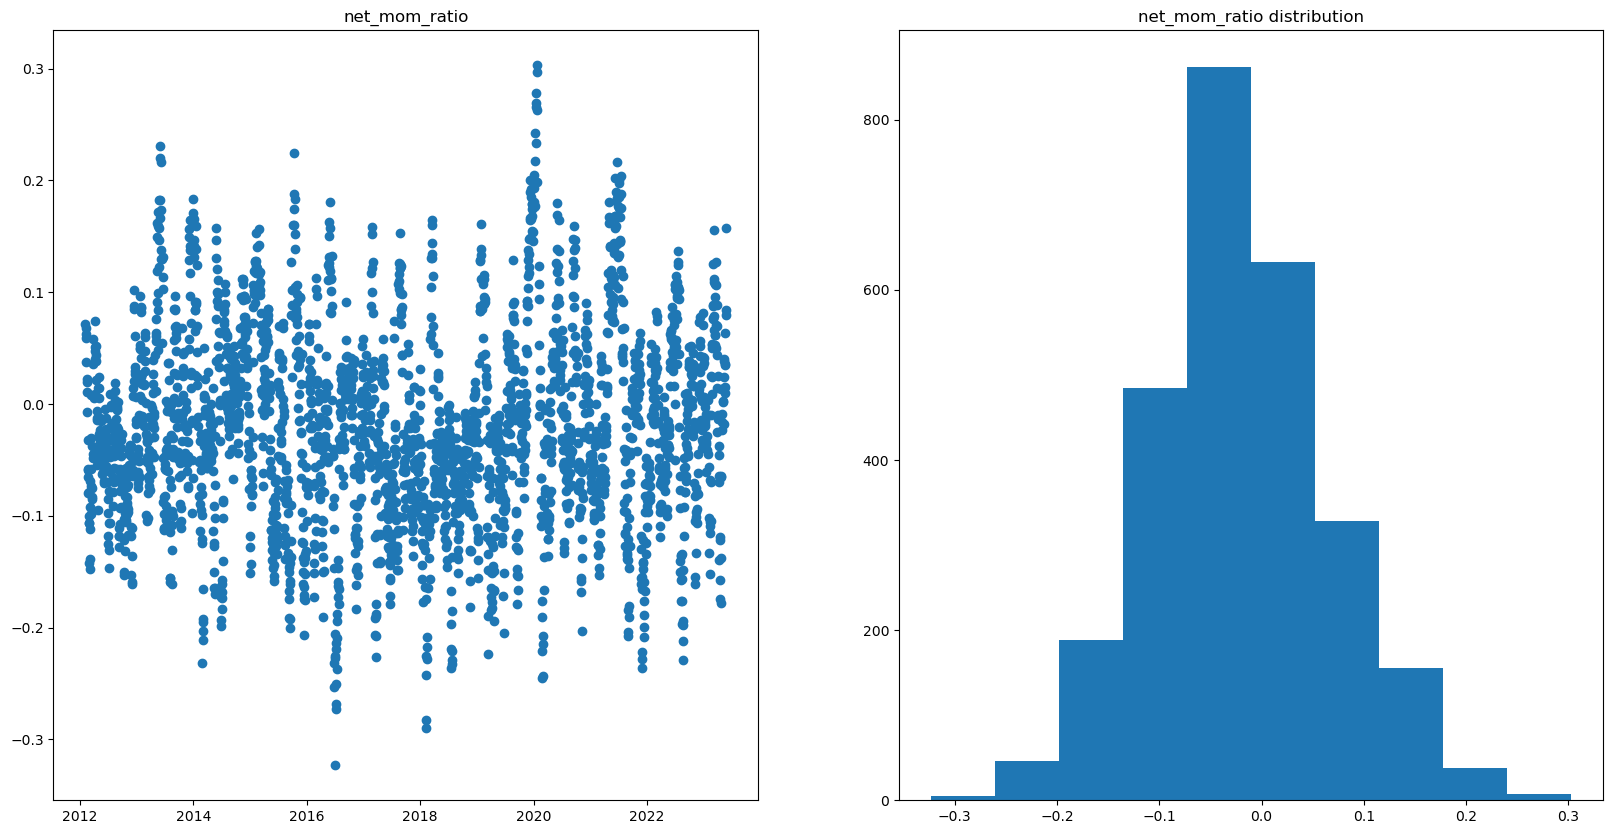

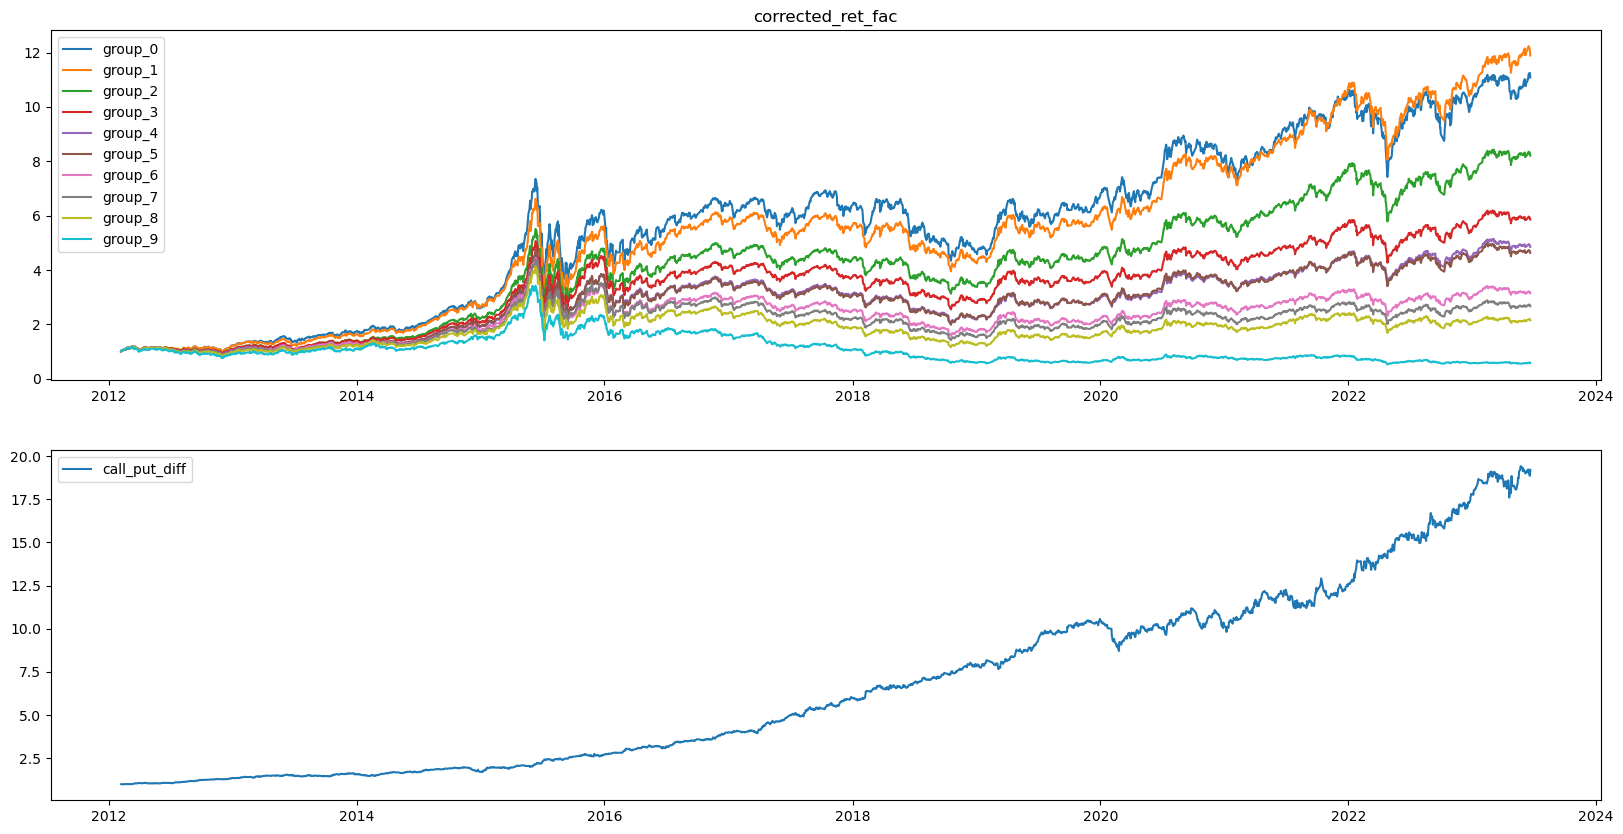

In [14]:
def z_score(g):
    return (g - g.mean()) / g.std()

df["fac1_z"] = df.groupby("time")["fac1"].apply(z_score)
df["fac2_z"] = df.groupby("time")["fac2"].apply(z_score)
df["corrected_ret_fac"] = df["fac1_z"] + df["fac2_z"]

tactic_3 = show_mom_back(df, fac_col = "corrected_ret_fac", ret_col = "ret_20_after")
show_tactic(tactic_3)
tactic_3_df = back_trade(df[["time", "code", "corrected_ret_fac"]], tar_col = "corrected_ret_fac")
show(tactic_3_df, "corrected_ret_fac", Type = 1)


作为单因子来说，效果已经非常好了

#### 日内收益率的可知性

接下来，我们按照日内收益率来计算和修正反转因子，为了明确比较基准，我们先对传统日内反转因子的计算方式和绩效表现加以简单说明，计算方式为：

计算每只股票t 日的日内收益率，即使用t 日收盘价除以t 日的开盘价后减1。

计算过去20 个交易日的日内收益率的平均值，记为本月的传统日内反转因子

先来看看传统日内反转因子的表现

net_mom_ratio > 0 的比例为： 0.47215143793228975
Avg_net_mom_ratio:  -0.008177562542194296
Stable_net_mom_ratio:  -0.07702023870623158


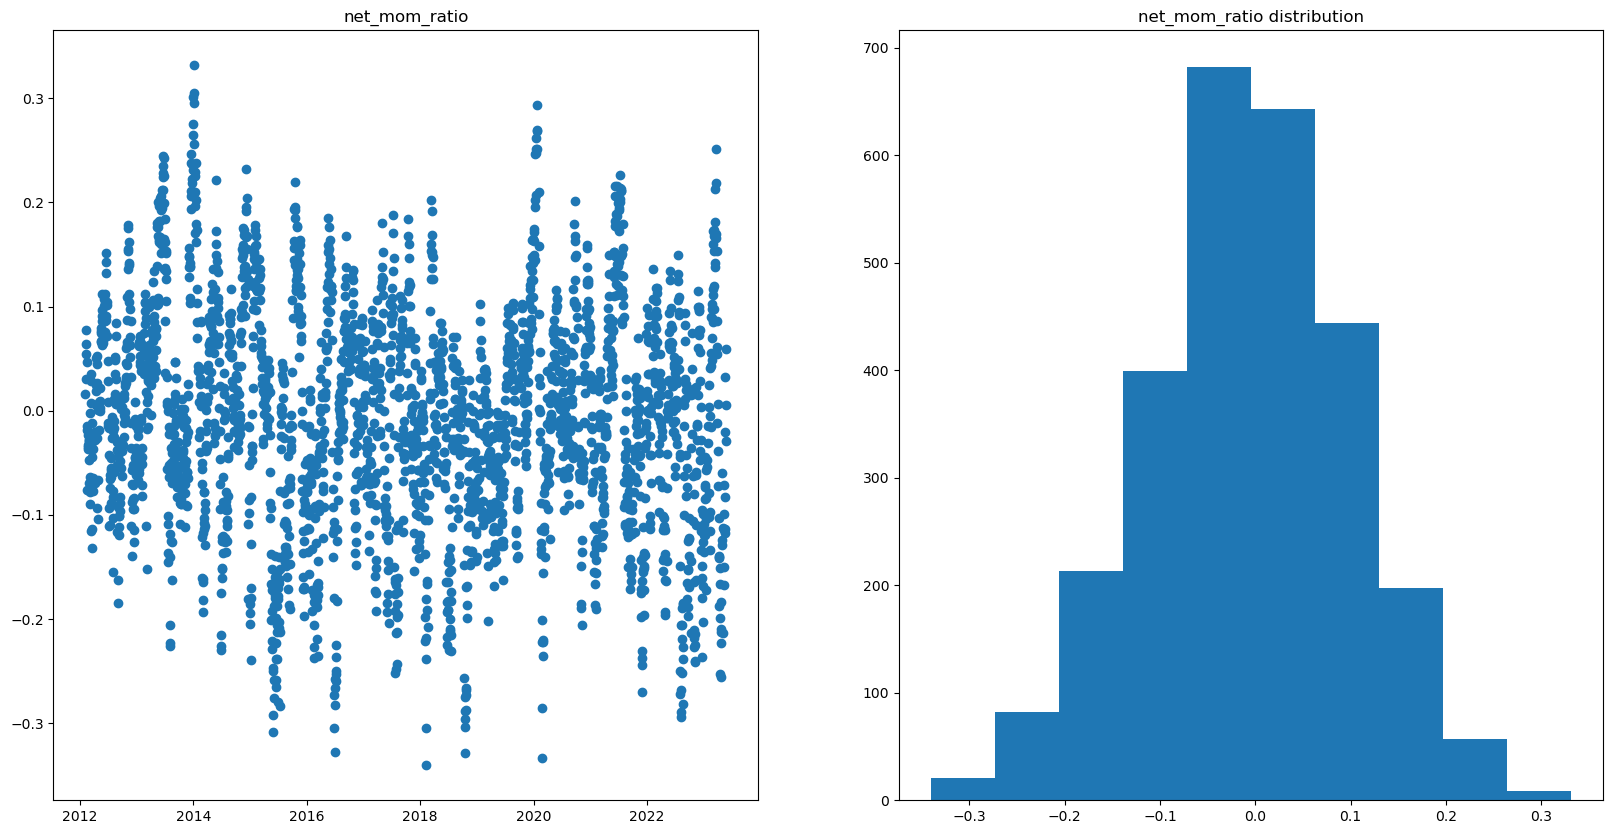

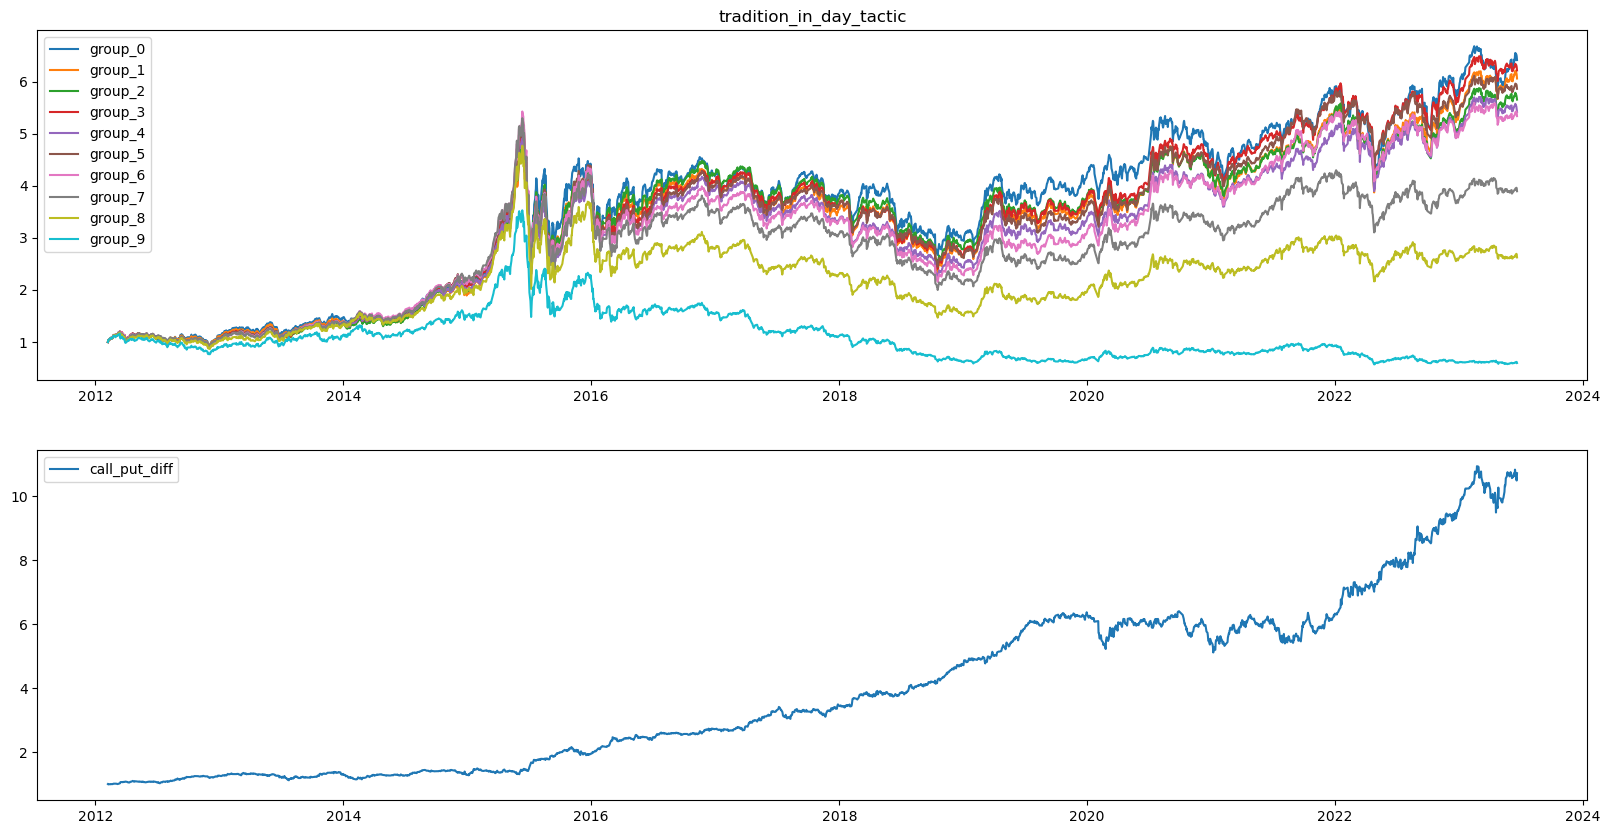

In [15]:
def calc_in_day_ret_mean(df):
    g = df.rolling(20)["ret_in_day"].apply(np.mean)
    df["ret_in_day_20"] = g
    return df

df["ret_in_day"] = df["close"] / df["open"] - 1
df = df.groupby("code").apply(calc_in_day_ret_mean)

tradtion_in_day_tactic = show_mom_back(df, fac_col = "ret_in_day_20", ret_col = "ret_20_after")
show_tactic(tradtion_in_day_tactic)
tradtion_in_day_tactic_df = back_trade(df[["time", "code", "ret_in_day_20"]], tar_col = "ret_in_day_20")
show(tradtion_in_day_tactic_df, "tradition_in_day_tactic", Type = 1)

#### 日内收益率波动率的可知性

与日间收益率波动率计算方式类似，我们以日内收益率过去 20 日的标准差作为日内收益率波动率，

以日内收益率波动率小于市场均值的股票为硬币型股票，波动率大于市场均值的股票为球队型股票，

将球队型股票的过去20日平均日内收益乘以 1，硬币型股票的乘以 -1 ，得到日内收益率波动率的可知性因子

net_mom_ratio > 0 的比例为： 0.3771386967601019
Avg_net_mom_ratio:  -0.019253555439651994
Stable_net_mom_ratio:  -0.23408366031939148


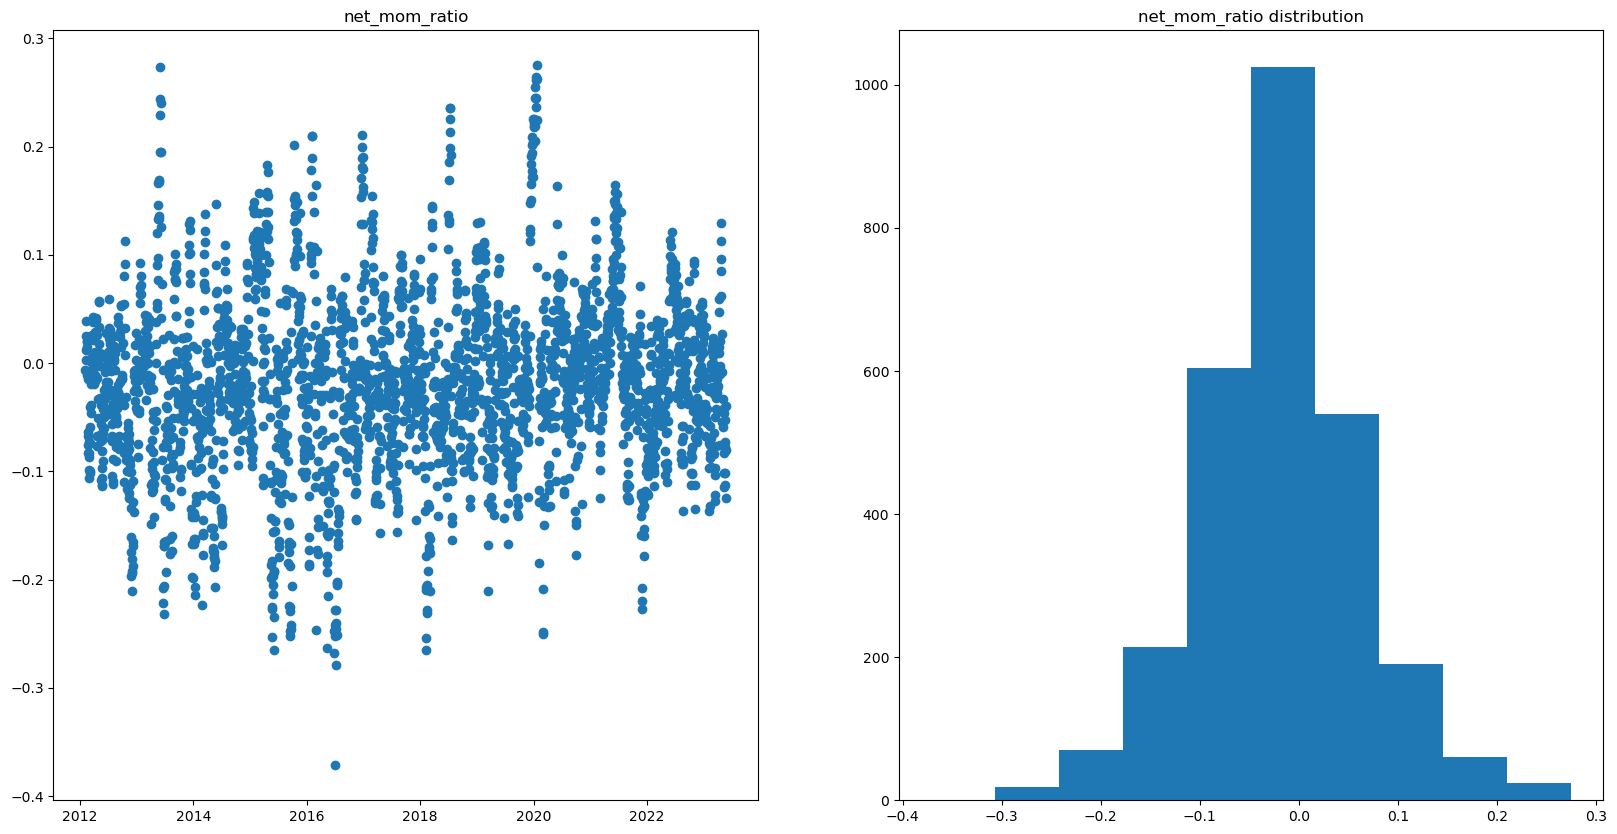

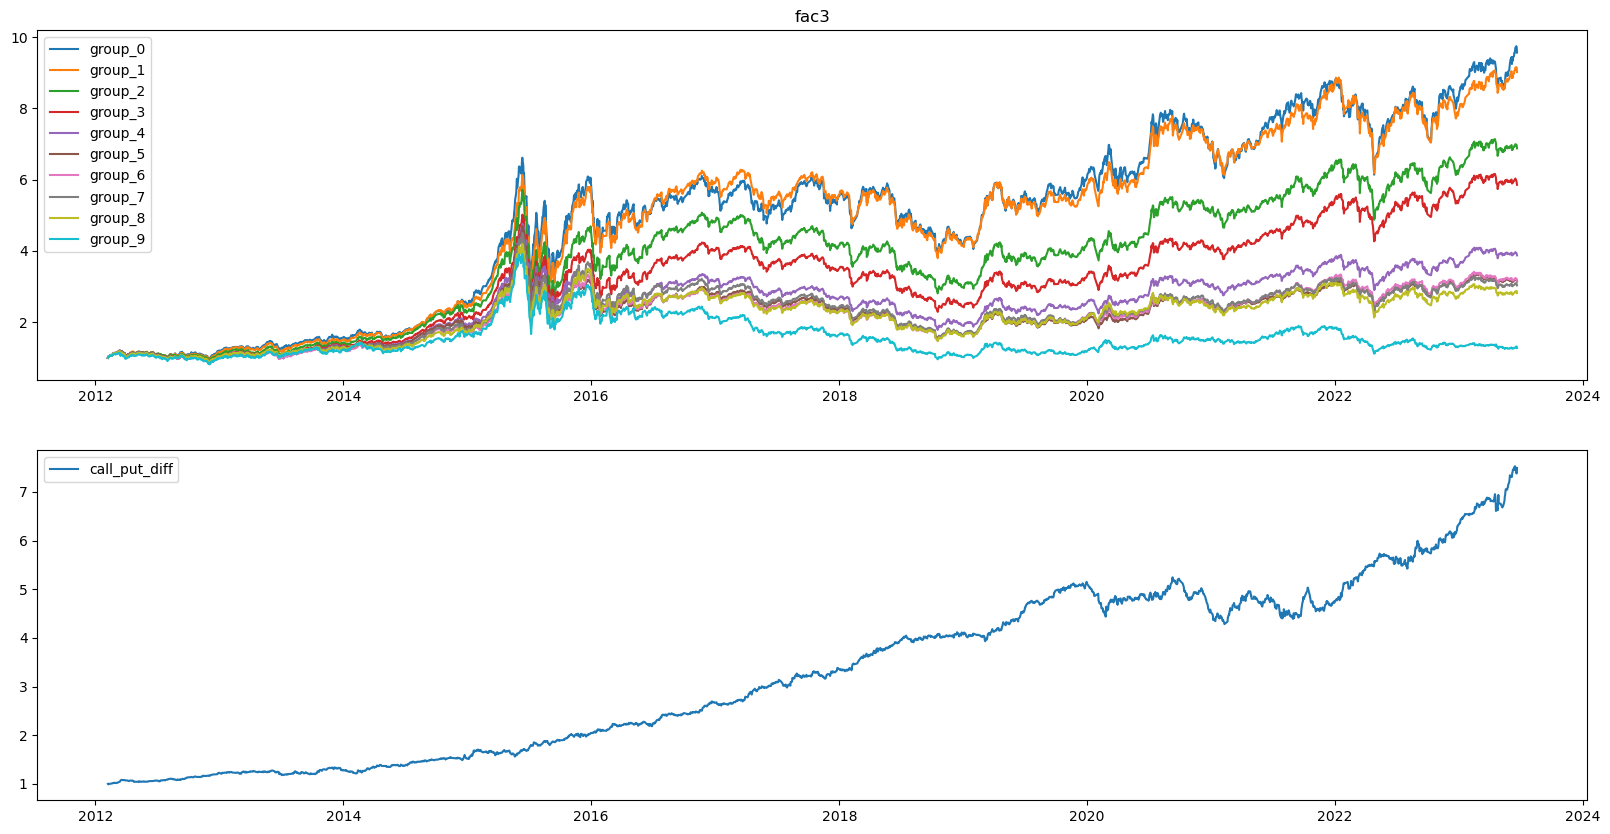

In [16]:
# 首先我们来计算过去 20 天的日内收益率的 std
def calc_vol(df):
    g = df.rolling(20)["ret_in_day"].apply(np.std)
    df["Vol_in_day"] = g
    return df
df = df.groupby("code").apply(calc_vol)

# 然后我们来计算过去 20 天的日内收益率std的均值

g = df.groupby("time", as_index = False)["Vol_in_day"].mean()
g.columns = ["time", "market_avg_vol_in_day"]
df = pd.merge(df, g, on = 'time', how = 'left')


df["flag"] = df.apply(lambda x: 1 if x["Vol_in_day"] > x["market_avg_vol_in_day"] else -1, axis = 1)
df["fac3"] = df["ret_20"] * df["flag"]

tactic_3 = show_mom_back(df, fac_col = "fac3", ret_col = "ret_20_after")
show_tactic(tactic_3)
tactic_3_df = back_trade(df[["time", "code", "fac3"]], tar_col = "fac3")
show(tactic_3_df, "fac3", Type = 1)

表现还算可以把，至少没有大规模回车，但是看起来中间某段时间的适用性不是非常好

怪不得研报不放日内改进前的多空收益比TAT，原来他这个改进多空收益上表现确实一般

但是从净动量比例来看，明显下降了，说明还是对动量效应和反转效应做了更准确的预测

#### 日内收益率 - 换手率的可知性

和上面的处理方式是一样的，这里就不多说了

net_mom_ratio > 0 的比例为： 0.36257735711685474
Avg_net_mom_ratio:  -0.021495695326782693
Stable_net_mom_ratio:  -0.2737194672371381


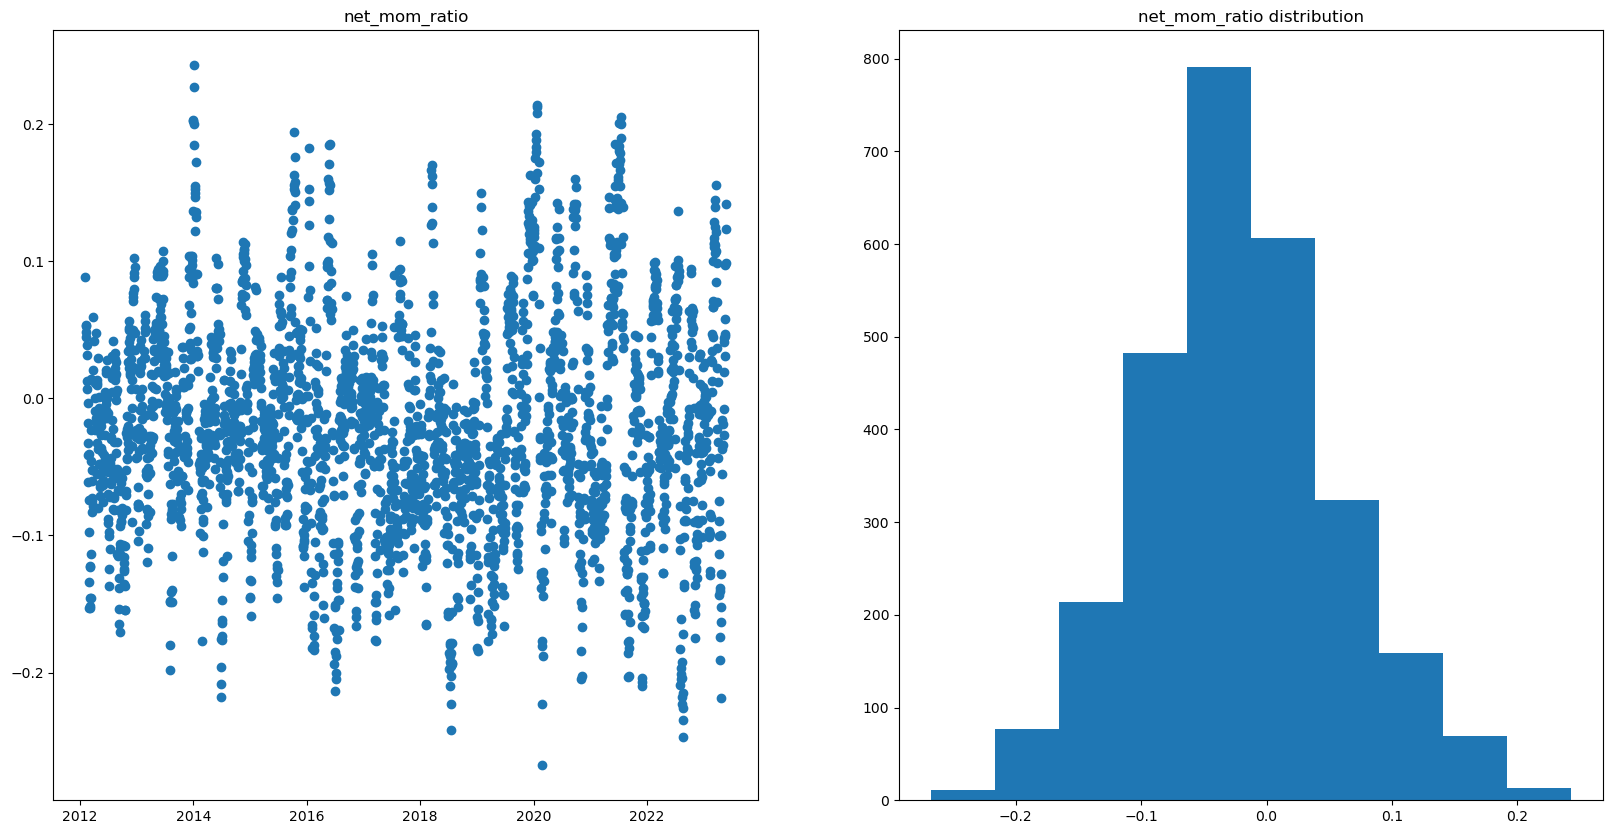

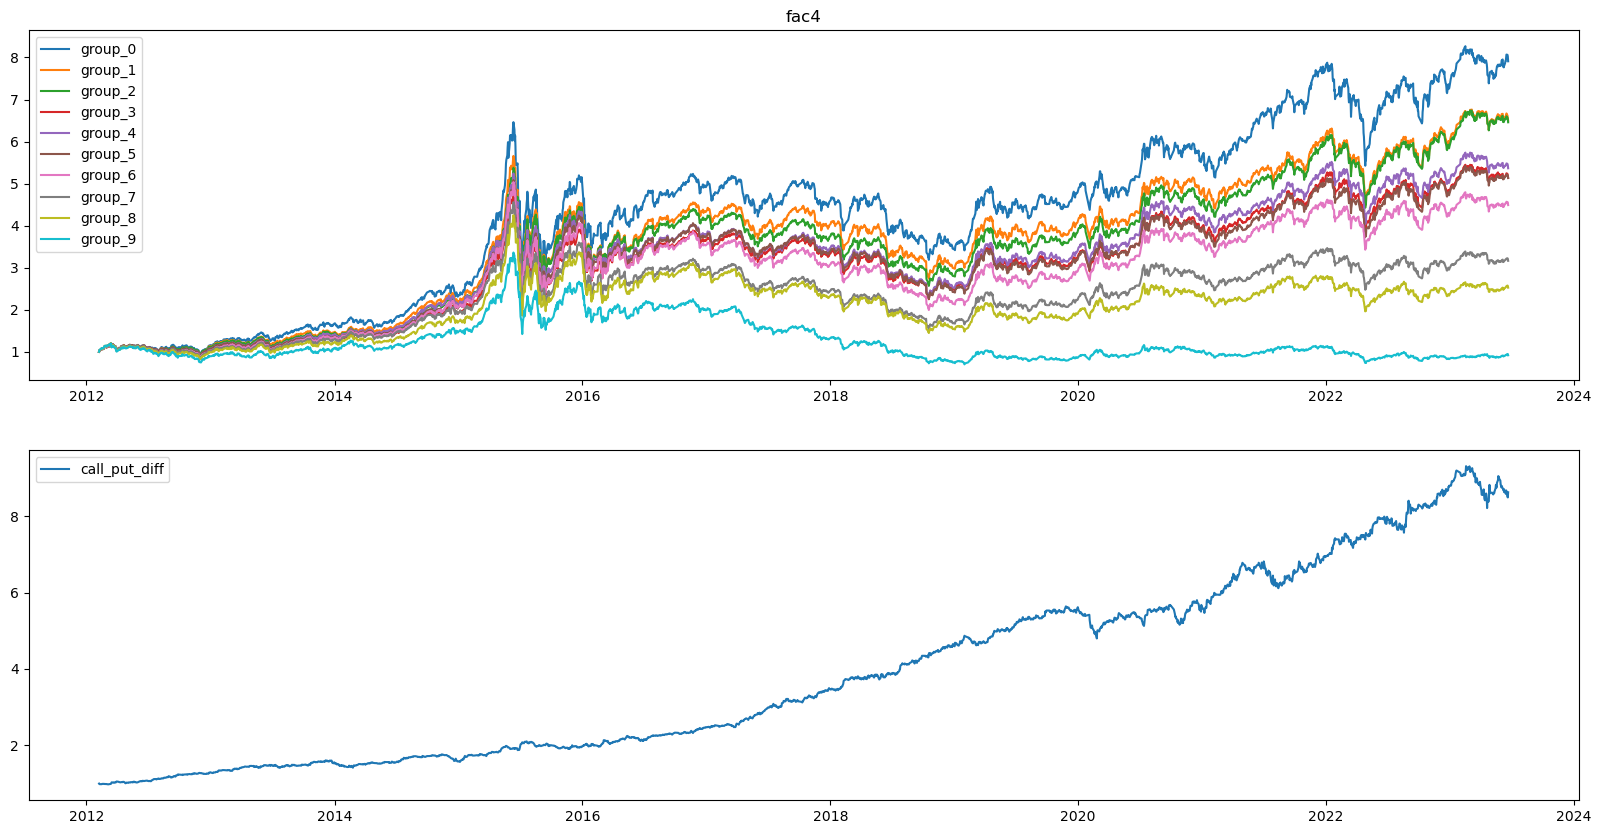

In [17]:
df["flag"] = df.apply(lambda x: 1 if x["turnover_rate_change"] > x["turnover_rate_change_mean"] else -1, axis = 1)
df["my_ret"] = df.apply(lambda x: (x["ret_in_day"]) * x["flag"], axis = 1)

def calc_fac4(df):
    g = df.rolling(20)["my_ret"].apply(np.mean)
    df["fac4"] = g
    return df

df = df.groupby("code").apply(calc_fac4)

tactic_4 = show_mom_back(df, fac_col = "fac4", ret_col = "ret_20_after")
show_tactic(tactic_4)
tactic_4_df = back_trade(df[["time", "code", "fac4"]], tar_col = "fac4")
show(tactic_4_df, "fac4", Type = 1)

但是这个改进是有价值的，多空收益变得稳定了，体现到投资组合上表现为胜率变高了

多空收益的下降一定程度上是因为我们把一些原本属于动量效应的股票识别为了反转效应，导致了多空收益的下降

#### 修正 - 日内收益率因子

和前面一样，将波动率的和换手率的两个因子合成成一个因子即可

net_mom_ratio > 0 的比例为： 0.3687659264652348
Avg_net_mom_ratio:  -0.01877673324744785
Stable_net_mom_ratio:  -0.22380152047143329


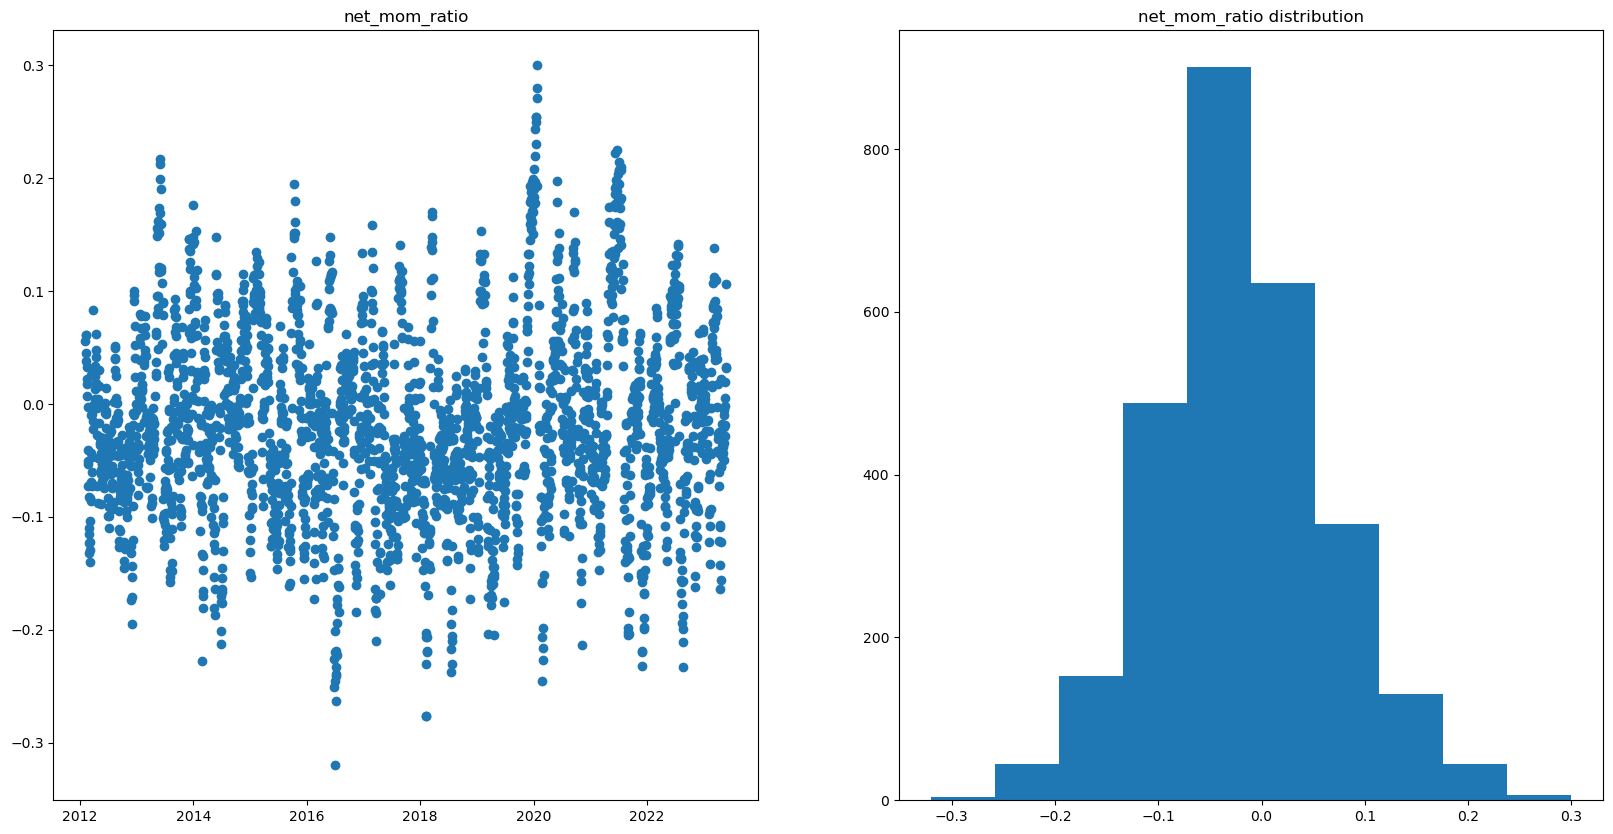

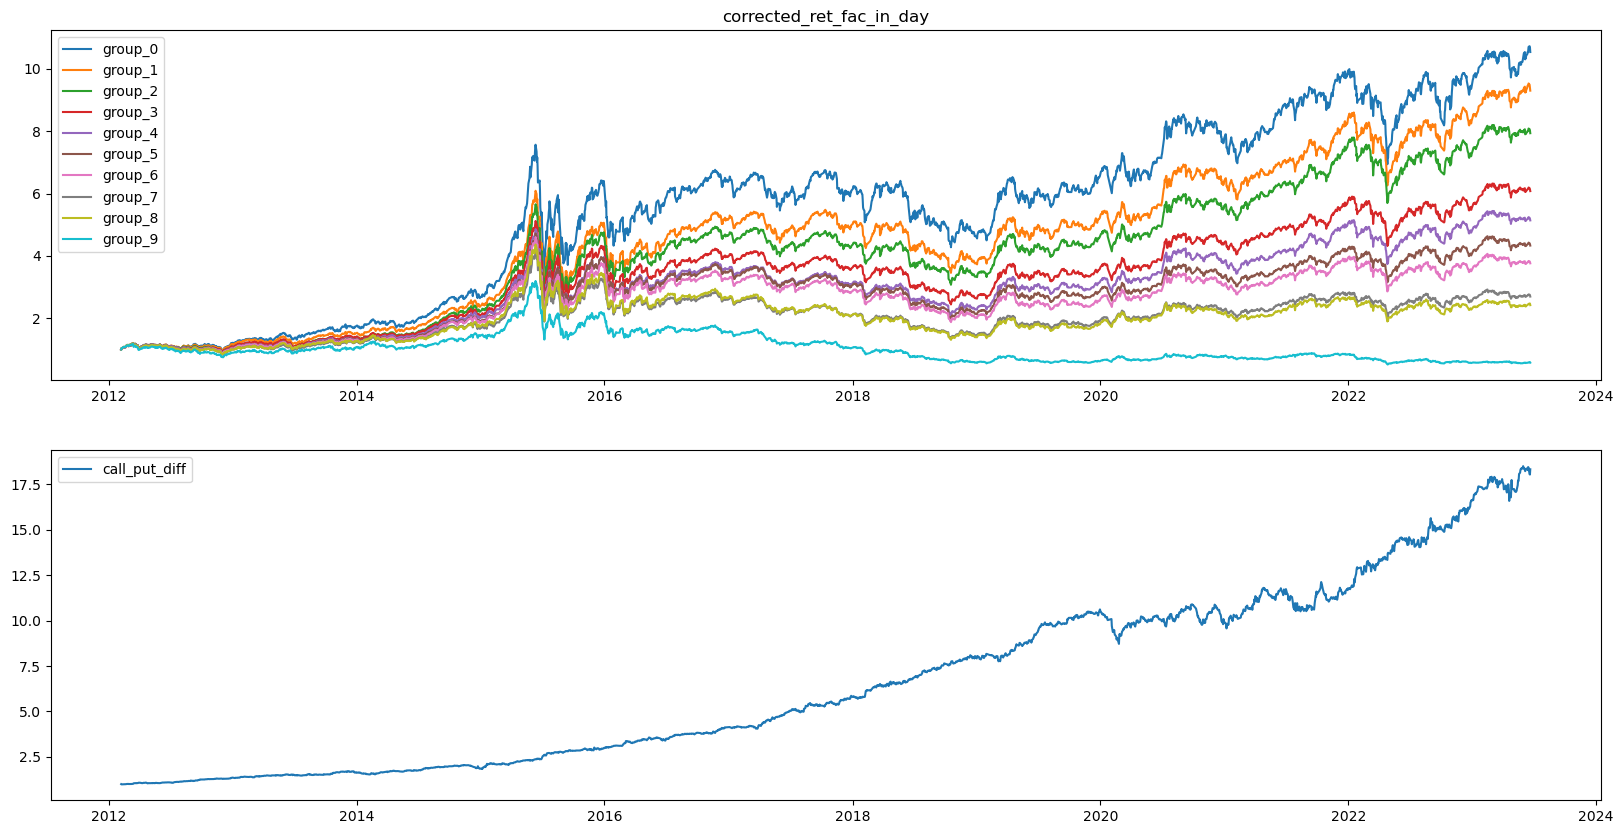

In [18]:
df["fac3_z"] = df.groupby("time")["fac3"].apply(z_score)
df["fac4_z"] = df.groupby("time")["fac4"].apply(z_score)
df["corrected_ret_fac_in_day"] = df["fac3_z"] + df["fac4_z"]

tactic_in_day = show_mom_back(df, fac_col = "corrected_ret_fac_in_day", ret_col = "ret_20_after")
show_tactic(tactic_in_day)
tactic_in_day_df = back_trade(df[["time", "code", "corrected_ret_fac_in_day"]], tar_col = "corrected_ret_fac_in_day")
show(tactic_in_day_df, "corrected_ret_fac_in_day", Type = 1)

也可以看成是非常稳定的因子了

#### 隔夜收益率的可知性

除日间收益率、日内收益率外，隔夜收益率也受到投资者较高的关注，我们参考传统日间反转因子构建方式，构建传统隔夜涨跌因子：

计算每只股票t 日的隔夜收益率，即使用t 日开盘价除以t-1 日的收盘价再减1。

计算过去20 个交易日的隔夜收益率的平均值，记为本月的传统隔夜涨跌因子.

注意这个因子的逻辑是，距离均值太小或者太大都不好，也就是两端差，中间好。

因为距离均值过远说明他的可知性相对较差，投资者每天都要分析是否会存在高开或者低开的现象，而几乎每天都是平开的股票则说明其可知性较高，投资者可以更加容易地做出决策。

我们可以直接对因子值取绝对值，来进行判断

net_mom_ratio > 0 的比例为： 0.6494357480888242
Avg_net_mom_ratio:  0.030923030075419047
Stable_net_mom_ratio:  0.3846589067971819


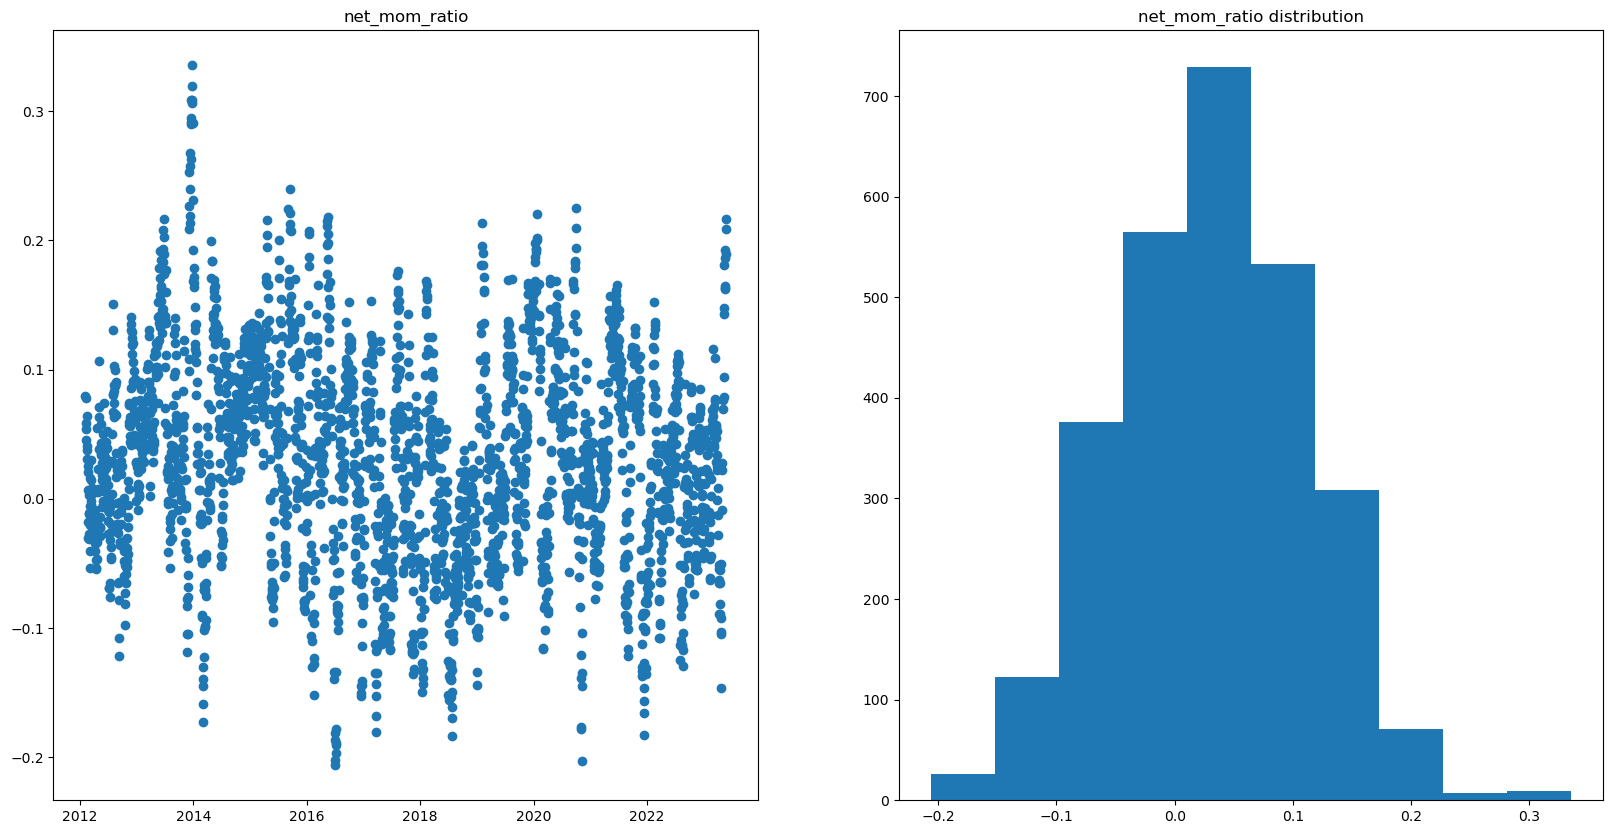

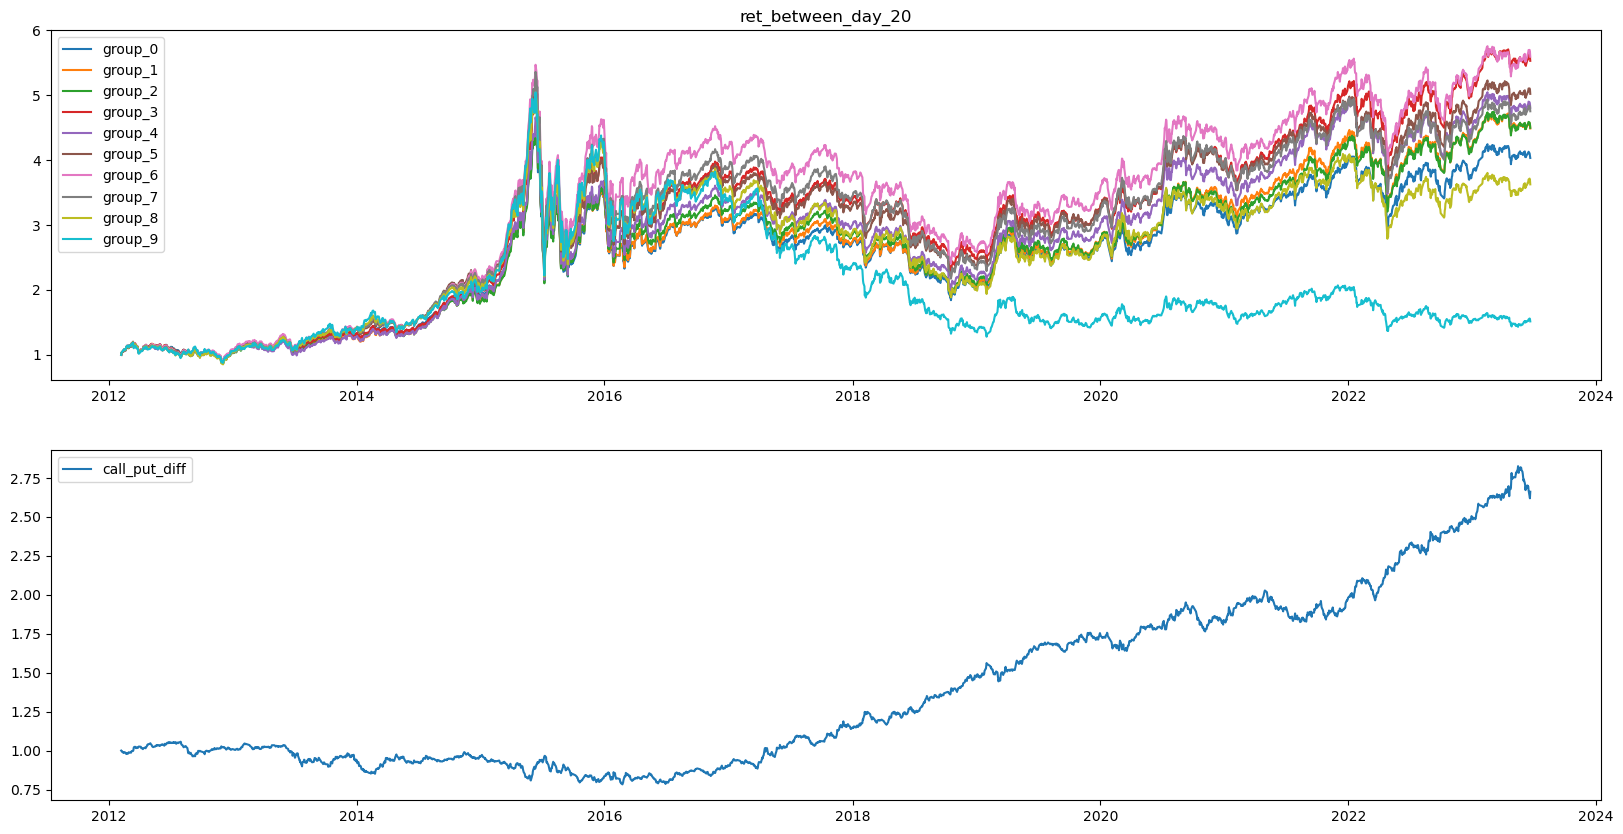

In [23]:
def calc_between_ret_mean(df):
    g = df.rolling(20)["ret_between_day"].apply(np.mean)
    df["ret_between_day_20"] = np.abs(g)
    return df


df["ret_between_day"] = df["open"] / df["pre_close"] - 1
df = df.groupby("code").apply(calc_between_ret_mean)

tradtion_between_tactic = show_mom_back(df, fac_col = "ret_between_day_20", ret_col = "ret_20_after")
show_tactic(tradtion_between_tactic)
tradtion_between_tactic_df = back_trade(df[["time", "code", "ret_between_day_20"]], tar_col = "ret_between_day_20")
show(tradtion_between_tactic_df, "ret_between_day_20", Type = 1)

看起传统的日间收益表现起来不太好。均净动量比例除以稳净动量比例的值也相对比较小

#### 隔夜收益率波动率的可知性

首先要计算过去20 个交易日的隔夜收益率的标准差，记为本月的隔夜收益率波动率因子

同样，我们以隔夜收益率波动率小于市场均值的股票为硬币型股票，波动率大于市场均值的股票为球队型股票，

将球队型股票的过去20日平均隔夜收益乘以 1，硬币型股票的乘以 -1 ，得到隔夜收益率波动率的可知性因子

net_mom_ratio > 0 的比例为： 0.6494357480888242
Avg_net_mom_ratio:  0.030923030075419047
Stable_net_mom_ratio:  0.3846589067971819


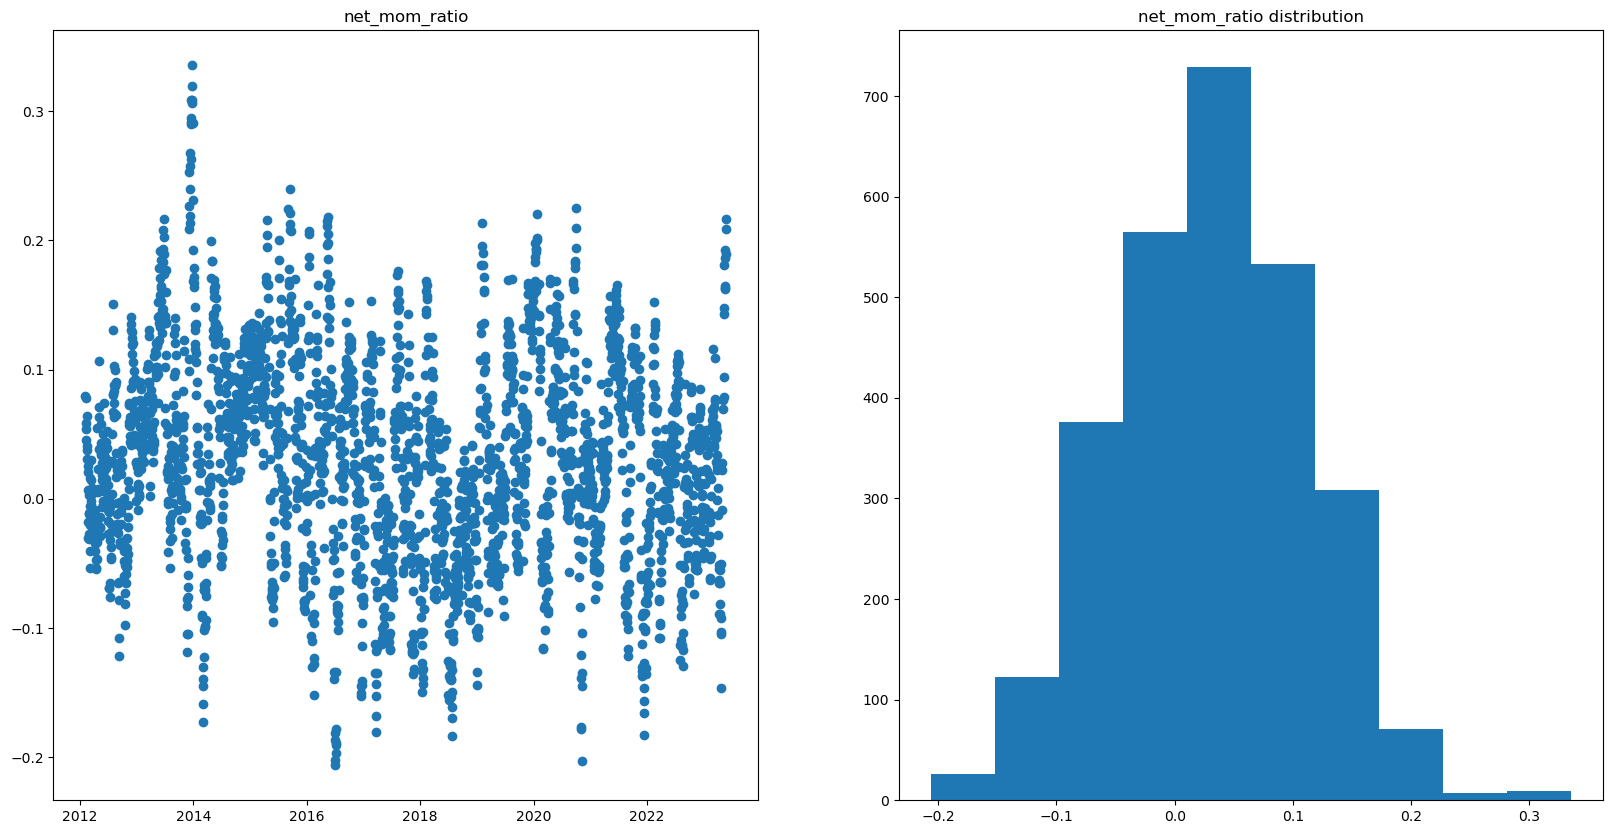

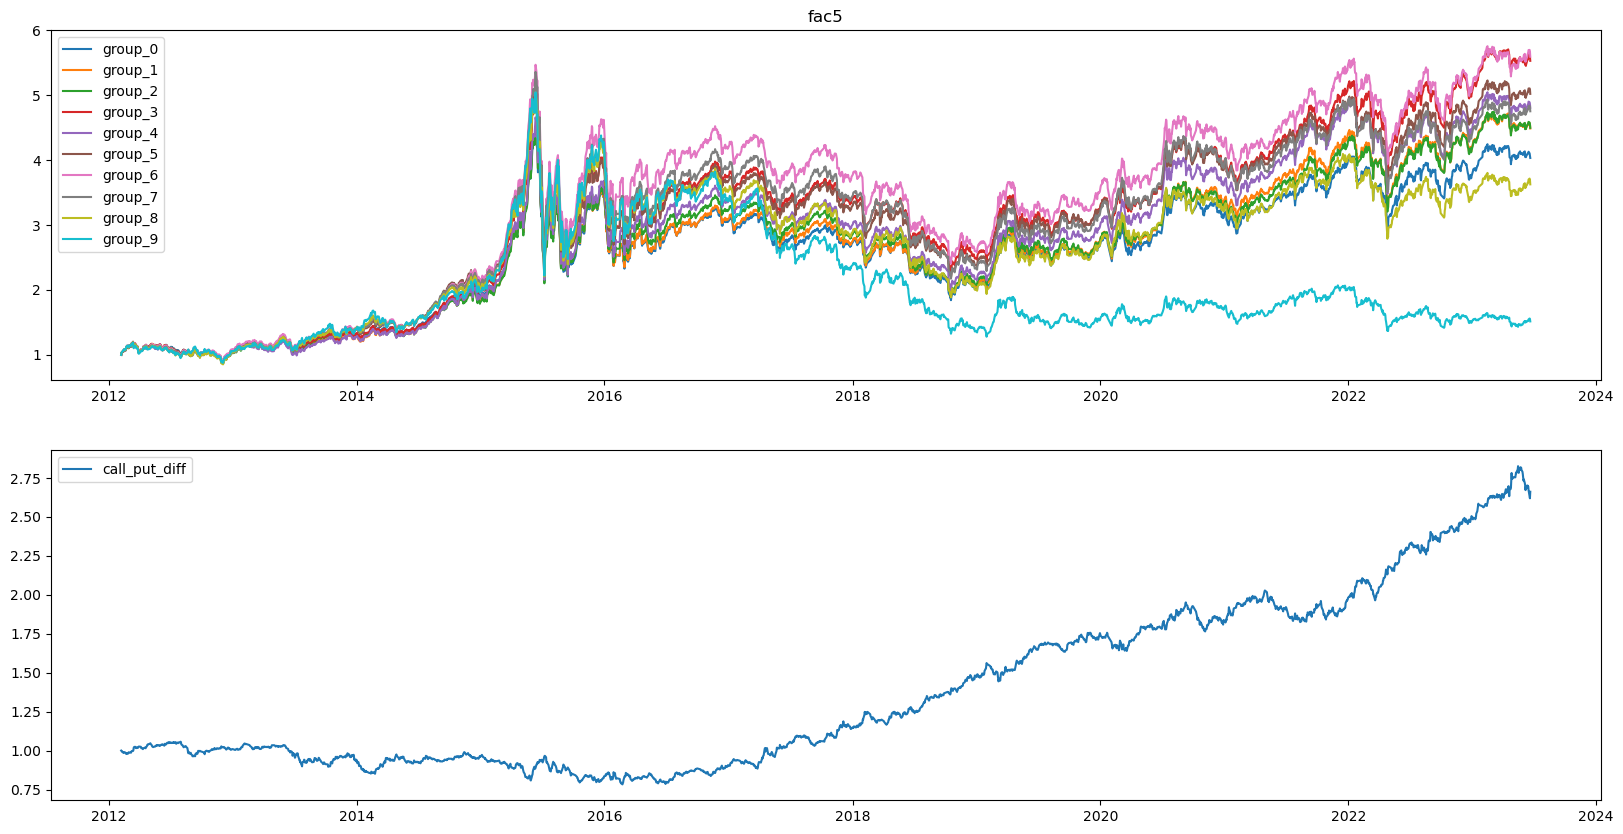

In [27]:
# 首先我们来计算过去 20 天的隔夜收益率的 std

def calc_after_night_vol(df):
    g = df.rolling(20)["ret_between_day"].apply(np.std)
    df["Vol_after_night"] = g
    return df

df = df.groupby("code").apply(calc_after_night_vol)

# 然后我们来计算过去 20 天的隔夜收益率std的均值

g = df.groupby("time", as_index = False)["Vol_after_night"].mean()
g.columns = ["time", "market_avg_vol_after_night"]
df = pd.merge(df, g, on = 'time', how = 'left')

df["flag"] = df.apply(lambda x: 1 if x["Vol_after_night"] > x["market_avg_vol_after_night"] else -1, axis = 1)
df["fac5"] = df["ret_between_day_20"] * df["flag"]
df["fac5"] = np.abs(df["fac5"])

tactic_5 = show_mom_back(df, fac_col = "fac5", ret_col = "ret_20_after")
show_tactic(tactic_5)
tactic_5_df = back_trade(df[["time", "code", "fac5"]], tar_col = "fac5")
show(tactic_5_df, "fac5", Type = 1)

#### 隔夜收益率 - 换手率的可知性

同样，我们可以计算出换手率的可知性因子

net_mom_ratio > 0 的比例为： 0.6006552602839461
Avg_net_mom_ratio:  0.019597202992296697
Stable_net_mom_ratio:  0.2524780221018889


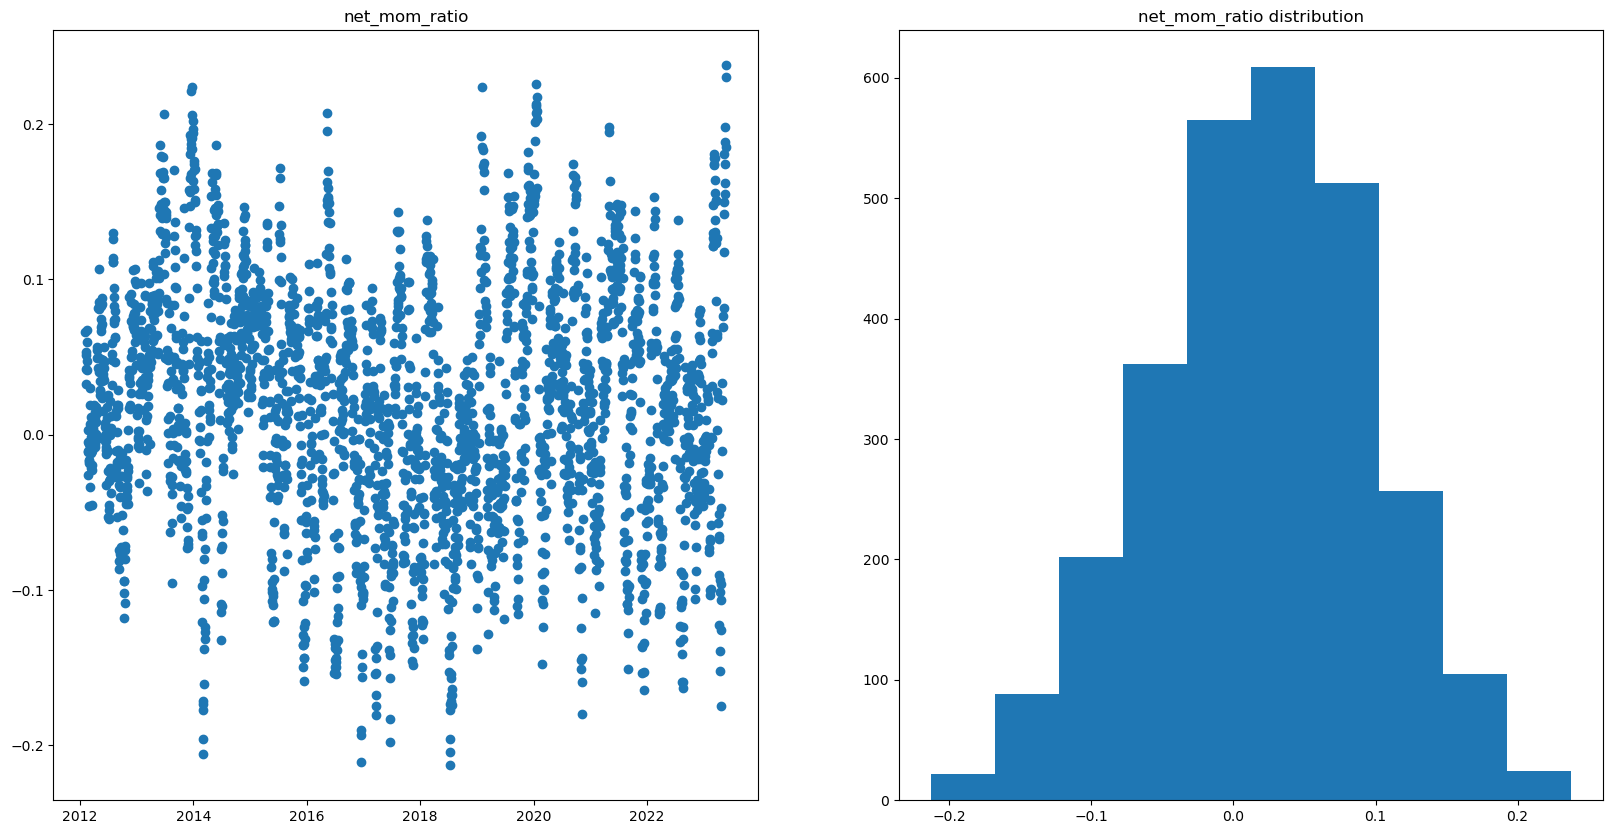

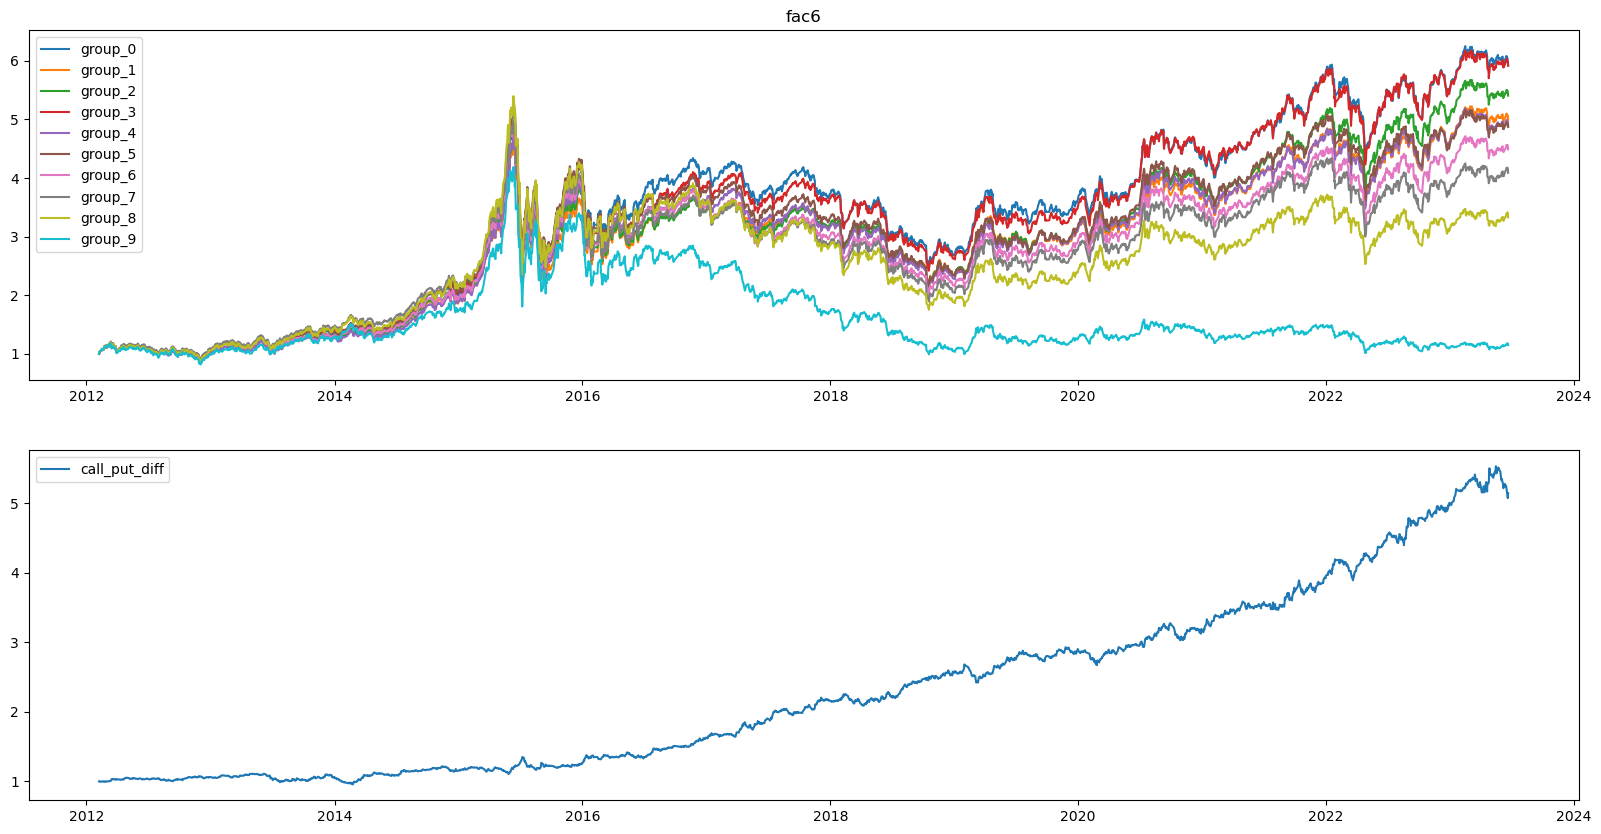

In [28]:
df["flag"] = df.apply(lambda x: 1 if x["turnover_rate_change"] > x["turnover_rate_change_mean"] else -1, axis = 1)
df["my_ret"] = df.apply(lambda x: (x["ret_between_day"]) * x["flag"], axis = 1)

def calc_fac6(df):
    g = df.rolling(20)["my_ret"].apply(np.mean)
    df["fac6"] = np.abs(g)
    return df

df = df.groupby("code").apply(calc_fac6)
tactic_6 = show_mom_back(df, fac_col = "fac6", ret_col = "ret_20_after")
show_tactic(tactic_6)
tactic_6_df = back_trade(df[["time", "code", "fac6"]], tar_col = "fac6")
show(tactic_6_df, "fac6", Type = 1)

#### 修正 - 隔夜收益率因子

最后，我们将两个因子合成，得到修正 - 隔夜收益率因子

net_mom_ratio > 0 的比例为： 0.5809974517655624
Avg_net_mom_ratio:  0.017592779834451178
Stable_net_mom_ratio:  0.19656188830077406


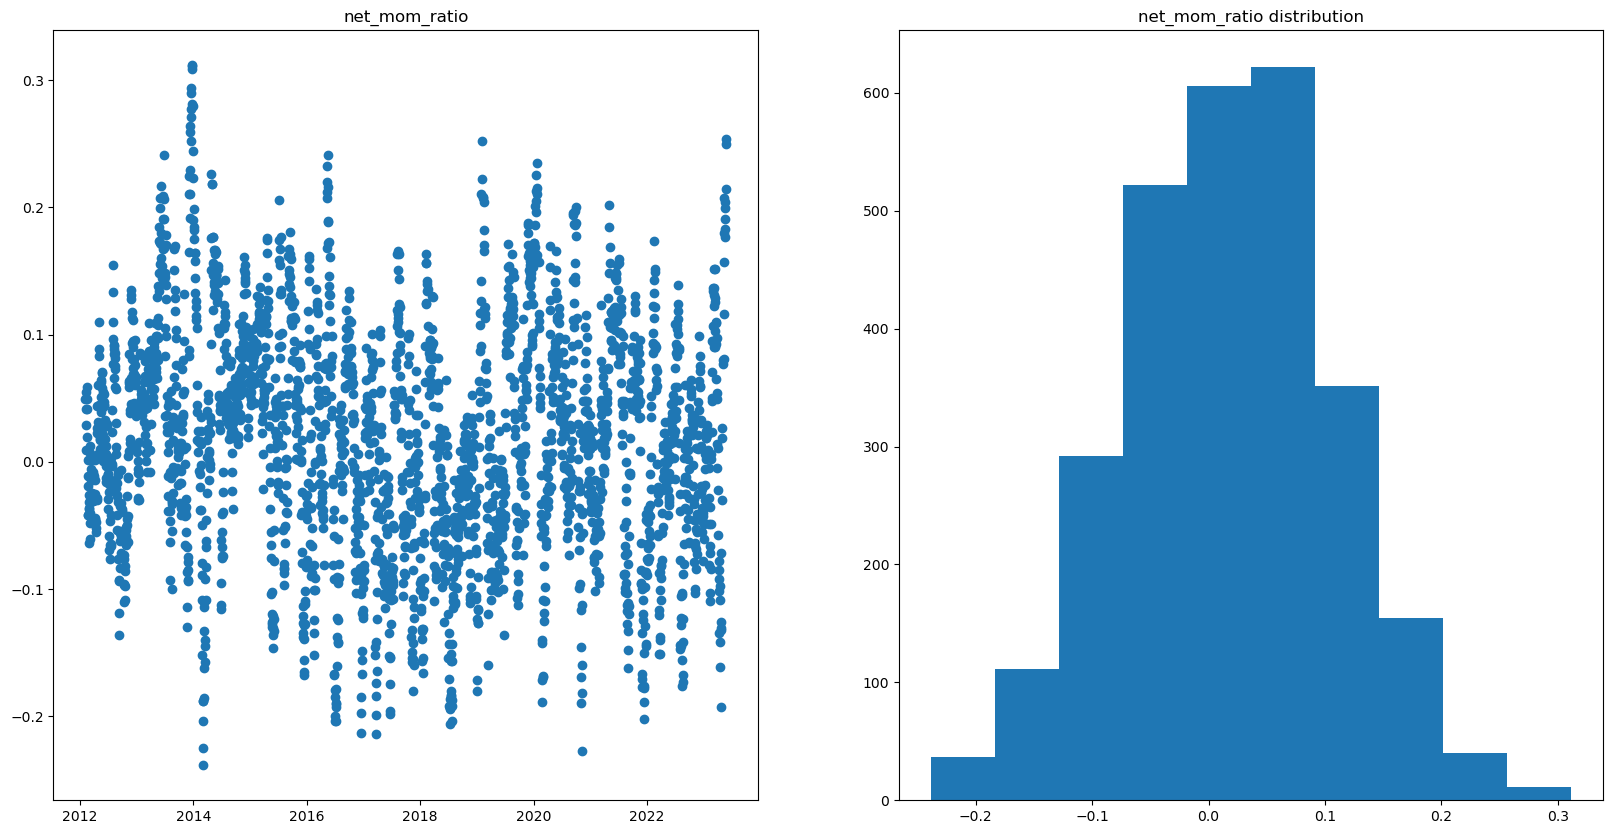

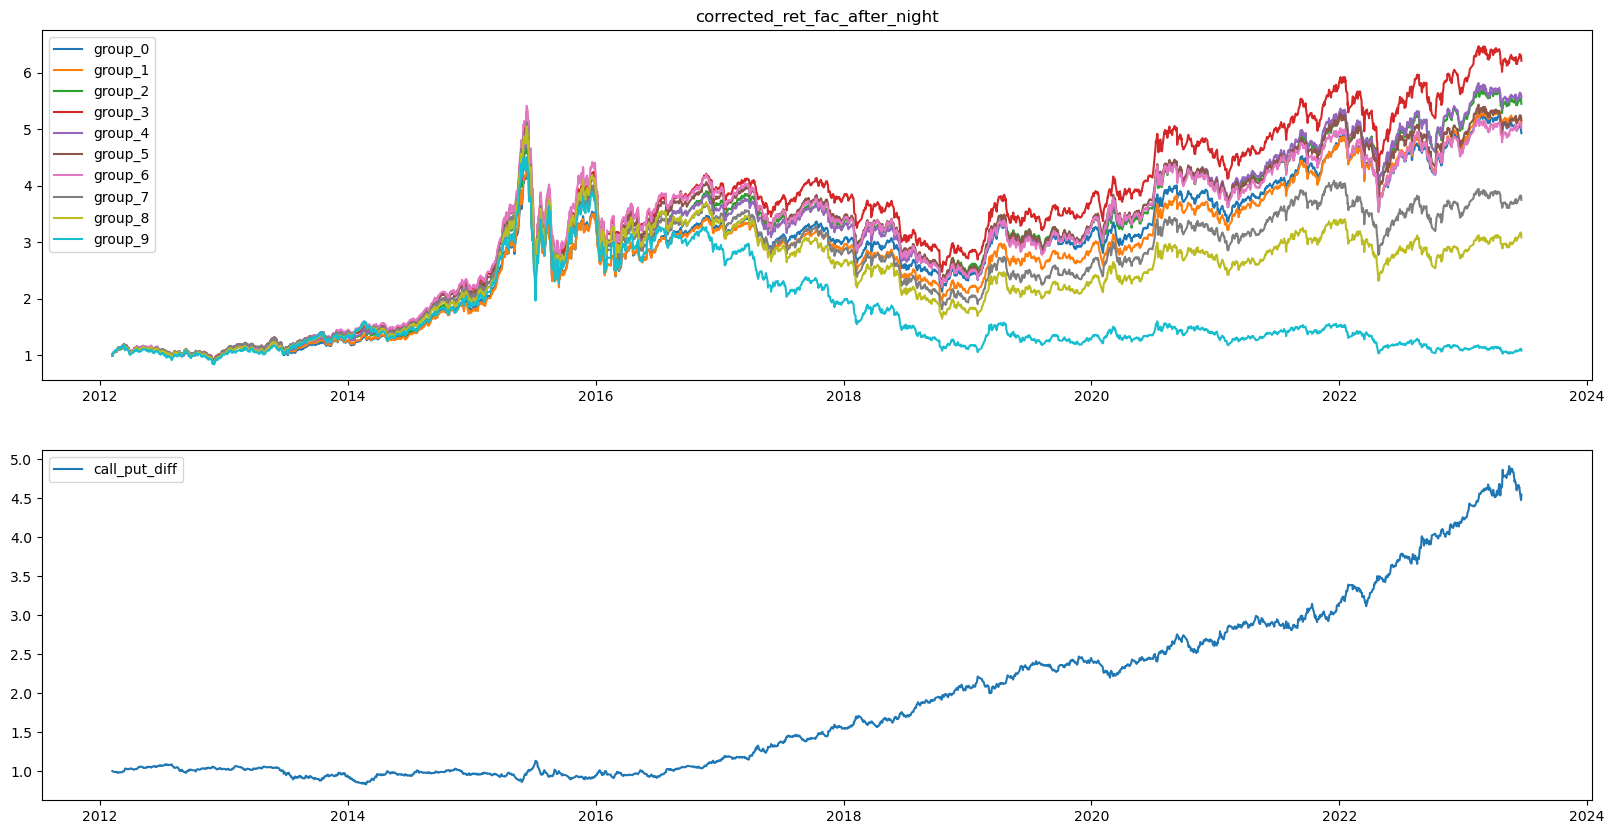

In [29]:
df["fac5_z"] = df.groupby("time")["fac5"].apply(z_score)
df["fac6_z"] = df.groupby("time")["fac6"].apply(z_score)
df["corrected_ret_fac_after_night"] = df["fac5_z"] + df["fac6_z"]

tactic_after_night = show_mom_back(df, fac_col = "corrected_ret_fac_after_night", ret_col = "ret_20_after")
show_tactic(tactic_after_night)
tactic_after_night_df = back_trade(df[["time", "code", "corrected_ret_fac_after_night"]], tar_col = "corrected_ret_fac_after_night")
show(tactic_after_night_df, "corrected_ret_fac_after_night", Type = 1)


#### 修正 - 动量反转因子

最后，我们将所有六个因子合成，得到我们的修正 - 动量反转因子

net_mom_ratio > 0 的比例为： 0.4270112850382235
Avg_net_mom_ratio:  -0.012995356604629407
Stable_net_mom_ratio:  -0.13907656787692296


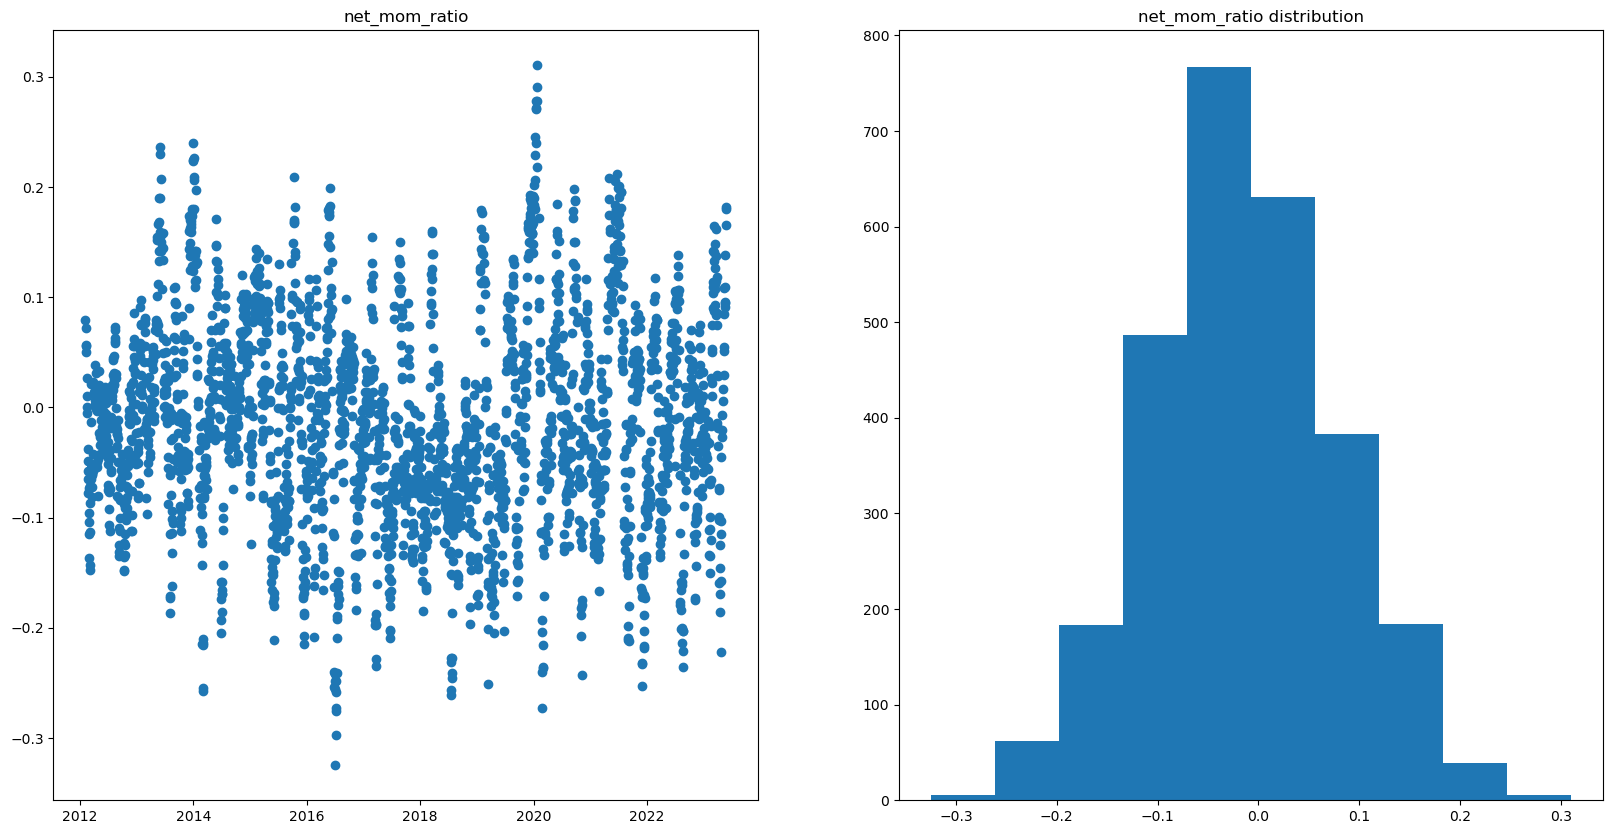

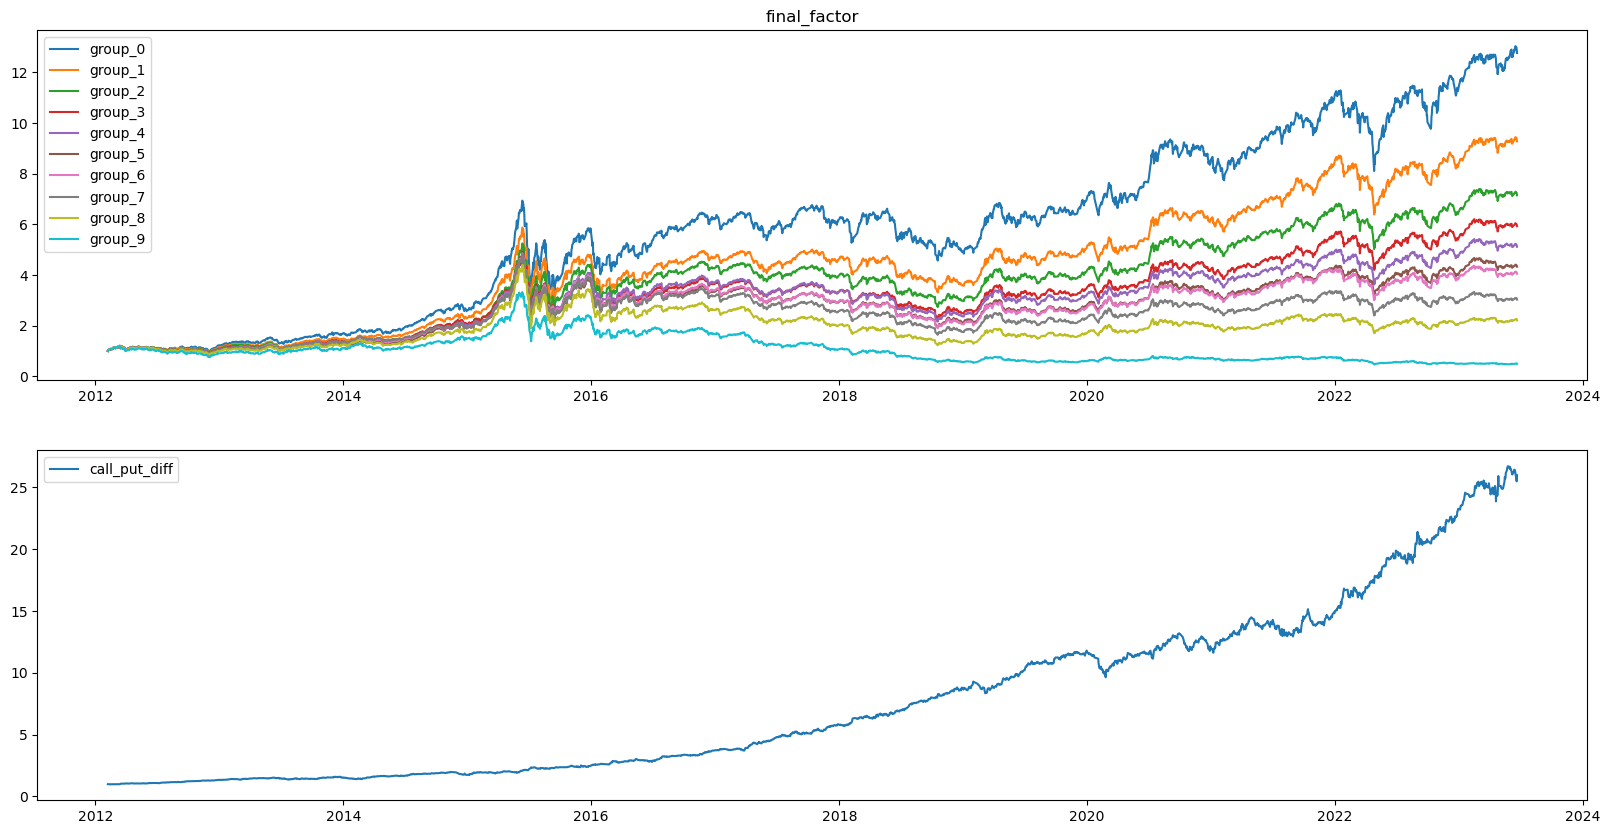

In [31]:
df["final_factor"] = df["corrected_ret_fac"] + df["corrected_ret_fac_in_day"] + df["corrected_ret_fac_after_night"]

tactic_final = show_mom_back(df, fac_col = "final_factor", ret_col = "ret_20_after")
show_tactic(tactic_final)
tactic_final_df = back_trade(df[["time", "code", "final_factor"]], tar_col = "final_factor")
show(tactic_final_df, "final_factor", Type = 1)